# Семинар 2. Статистический фундамент ML.

Теорию — i.i.d., ЗБЧ, ЦПТ, оценки параметров, доверительные интервалы, критерии значимости — разбирали на лекции, здесь её не повторяем.

На семинаре смотрим, как всё это работает на практике: генерируем данные с известными истинными параметрами и проверяем, действительно ли выполняются теоретические утверждения, которые мы доказывали на лекции. Заодно разберём пару сюжетов, которые на лекции были только упомянуты — например, почему для задач вроде оценки качества изображений (IQA) обычная MSE не годится и чем её заменить.

Для начала импортируем все нужные библиотеки и фиксируем `random seed` для воспроизводимости

In [ ]:
import numpy as np
import pandas as pd
import scipy.stats as sps
from scipy import optimize

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# --- Воспроизводимость ---
SEED = 42
rng = np.random.default_rng(SEED)

# --- Стиль графиков ---
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["figure.dpi"] = 100

PALETTE = sns.color_palette("Set2")

Вспомогательная функция для дальнейших графиков: рисует гистограмму выборки поверх теоретической плотности.

In [ ]:
def plot_hist_vs_density(samples, pdf_func=None, pdf_label="theoretical pdf",
                          bins=40, title="", ax=None, color=PALETTE[0]):
    if ax is None:
        fig, ax = plt.subplots()

    # density=True нормирует гистограмму для сравнения с плотностью
    ax.hist(samples, bins=bins, density=True, alpha=0.5, color=color,
             edgecolor="white", label="эмпирическая плотность распределения")

    if pdf_func is not None:
        xs = np.linspace(np.min(samples), np.max(samples), 400)
        ax.plot(xs, pdf_func(xs), color="firebrick", lw=2, label=pdf_label)

    ax.set_title(title)
    ax.legend()
    return ax

## 1. i.i.d. выборки

### 1.1 Как генерировать случайные величины

Компьютерные генераторы случайных чисел обычно позволяют легко получать случайную величину

$$
U\sim\operatorname{Uniform}(0,1).
$$

Но на практике нам часто нужны случайные величины с другими распределениями. Как получить, например, нормальную или экспоненциальную случайную величину, имея только генератор равномерного распределения?

Пусть $X$ — случайная величина с функцией распределения

$$
F_X(x)=P(X\le x).
$$

Если $F_X$ непрерывна и строго возрастает, то для

$$
U\sim\operatorname{Uniform}(0,1)
$$

можно взять

$$
\boxed{X=F_X^{-1}(U)}.
$$

Тогда $X$ имеет функцию распределения $F_X$.

Действительно,

$$
\begin{aligned}
P(X\le x)
&=P(F_X^{-1}(U)\le x)\\
&=P(U\le F_X(x))\\
&=F_X(x),
\end{aligned}
$$

поскольку $U$ равномерна на $[0,1]$.

Таким образом, **равномерное распределение можно превратить в случайную величину с практически любым заданным непрерывным распределением**, если мы умеем вычислять его обратную функцию распределения.

Этот метод называется **inverse transform sampling**.

Например, для экспоненциального распределения

$$
F_X(x)=1-e^{-\lambda x},\qquad x\ge0,
$$

получаем

$$
F_X^{-1}(u)=-\frac{1}{\lambda}\ln(1-u).
$$

Поэтому случайную величину

$$
X\sim\operatorname{Exp}(\lambda)
$$

можно сгенерировать следующим образом:

$$
U\sim\operatorname{Uniform}(0,1),
\qquad
X=-\frac{1}{\lambda}\ln(1-U).
$$

На практике мы будем использовать этот принцип не только для генерации данных, но и для **проверки теоретических результатов статистики с помощью симуляций**.


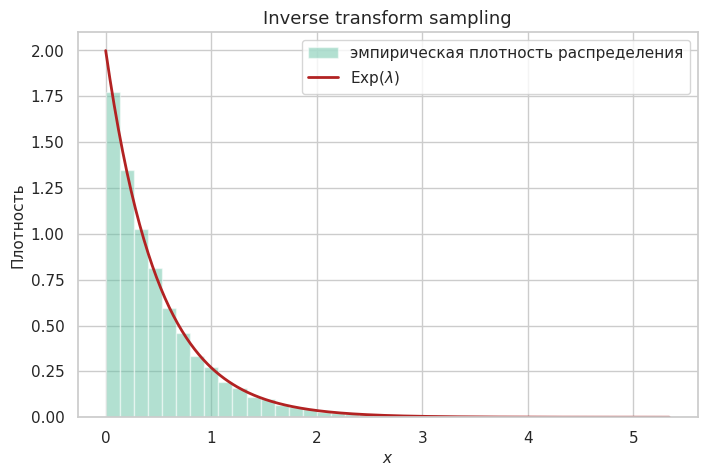

In [ ]:
# Параметр экспоненциального распределения
lambda_true = 2.0
n = 10_000

# Генерируем Uniform(0, 1)
u = rng.uniform(0, 1, size=n)

# Применяем обратную функцию распределения
x = -np.log(1 - u) / lambda_true

# Сравним гистограмму с теоретической плотностью
plot_hist_vs_density(
    x,
    pdf_func=lambda t: sps.expon.pdf(t, scale=1 / lambda_true),
    pdf_label=r"$\operatorname{Exp}(\lambda)$",
    bins=40,
    title="Inverse transform sampling"
)

plt.xlabel("$x$")
plt.ylabel("Плотность")
plt.show()

Возьмём смесь двух нормальных распределений — просто как пример нетривиального распределения, из которого удобно генерировать честные i.i.d.-наблюдения: каждое $X_i$ независимо и берётся из одного и того же распределения (плотность `mixture_pdf`).

Сравним гистограмму выборки с истинной плотностью и посмотрим, как это сравнение меняется с ростом $n$.

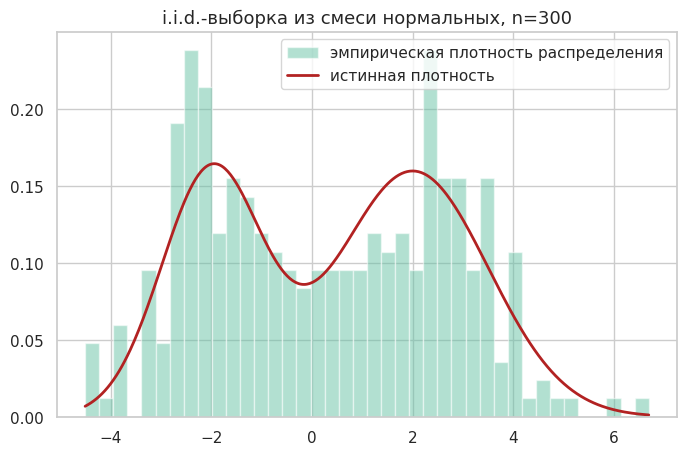

In [ ]:
# Генерация выборки из смеси двух нормальных распределений
def sample_mixture(n, rng, w=0.4, mu1=-2, sigma1=1.0, mu2=2, sigma2=1.5):
    """Выборка из смеси двух нормальных распределений."""
    is_first = rng.random(n) < w  # w - вероятность попасть в первую компоненту
    x = np.where(
        is_first,
        rng.normal(mu1, sigma1, n),
        rng.normal(mu2, sigma2, n),
    )
    return x

# Плотность смеси как взвешенная сумма плотностей компонент
def mixture_pdf(x, w=0.4, mu1=-2, sigma1=1.0, mu2=2, sigma2=1.5):
    return (w * sps.norm.pdf(x, mu1, sigma1)
            + (1 - w) * sps.norm.pdf(x, mu2, sigma2))

n = 300
x_iid = sample_mixture(n, rng)  # генерируем 300 независимых наблюдений

# Визуализация: гистограмма выборки и теоретическая плотность
fig, ax = plt.subplots()
plot_hist_vs_density(x_iid, mixture_pdf, "истинная плотность",
                      title=f"i.i.d.-выборка из смеси нормальных, n={n}", ax=ax)
plt.show()

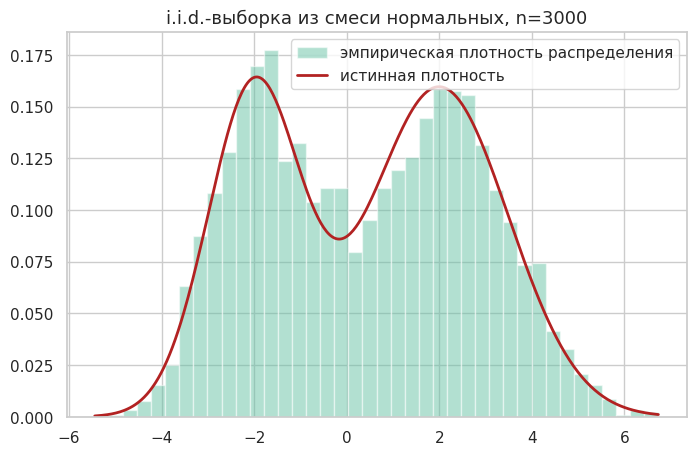

In [ ]:
#  меняем n
n = 3000
x_iid = sample_mixture(n, rng)

fig, ax = plt.subplots()
plot_hist_vs_density(x_iid, mixture_pdf, "истинная плотность",
                      title=f"i.i.d.-выборка из смеси нормальных, n={n}", ax=ax)
plt.show()

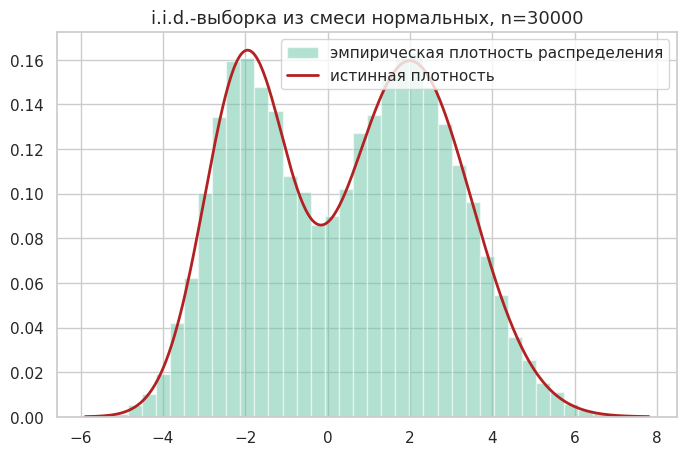

In [ ]:
#  меняем n
n = 30000
x_iid = sample_mixture(n, rng)

fig, ax = plt.subplots()
plot_hist_vs_density(x_iid, mixture_pdf, "истинная плотность",
                      title=f"i.i.d.-выборка из смеси нормальных, n={n}", ax=ax)
plt.show()

### 1.2. Когда i.i.d. нарушается

Сгенерируем версии выборки, в которых нарушается:

- **Независимость** (AR(1) процесс)
- **Одинаковое распределение** (матожидание меняется со временем)



AR(1): что это за процесс

$$
X_t = \mu + \varphi (X_{t-1}-\mu) + \varepsilon_t, \qquad \varepsilon_t\sim\mathcal N(0,\sigma_\varepsilon^2).
$$

Параметр $\varphi$ — коэффициент автокорреляции: чем он ближе к 1, тем сильнее процесс зависит от предыдущих значений. При $|\varphi|<1$ процесс стационарен — распределение $X_t$ не меняется со временем, но соседние наблюдения зависимы.

Чтобы дисперсия процесса совпадала с дисперсией i.i.d.-выборки (и сравнение было честным), дисперсию шума $\varepsilon_t$ берём равной $\sigma_\varepsilon^2 = \sigma^2(1-\varphi^2)$ — это.

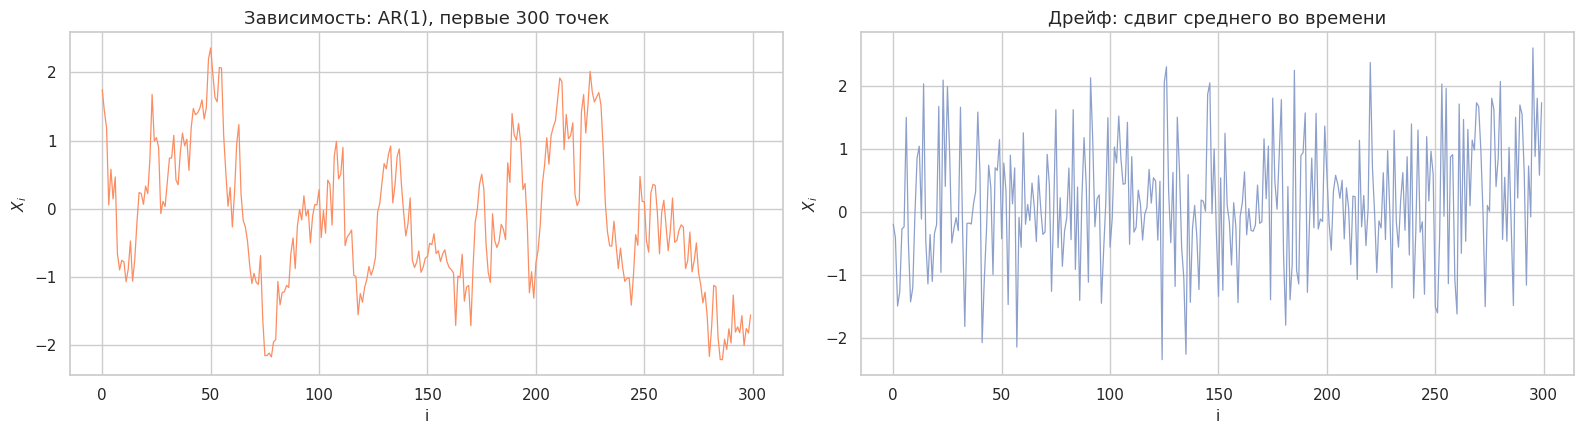

In [ ]:
# AR(1) процесс: зависимые наблюдения с автокорреляцией
def sample_ar1(n, rng, mu=0.0, sigma=1.0, phi=0.9):
    """Зависимые наблюдения: AR(1)-процесс с тем же стационарным mu, sigma."""
    innov_std = sigma * np.sqrt(1 - phi**2)  # дисперсия инноваций для стационарности
    x = np.zeros(n)
    x[0] = rng.normal(mu, sigma)
    for t in range(1, n):
        x[t] = mu + phi * (x[t - 1] - mu) + rng.normal(0, innov_std)
    return x

# Дрейф среднего: нестационарность, распределение меняется со временем
def sample_drift(n, rng, mu_start=0.0, mu_end=3.0, sigma=1.0):
    """Неодинаковое распределение: среднее плавно меняется во времени."""
    mus = np.linspace(mu_start, mu_end, n)  # линейно увеличиваем матожидание
    return rng.normal(mus, sigma)

n = 3000
x_dep = sample_ar1(n, rng)
x_drift = sample_drift(n, rng)

# Визуализация первых 300 точек для демонстрации структуры зависимостей
fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))
axes[0].plot(x_dep[:300], lw=0.9, color=PALETTE[1])
axes[0].set_title("Зависимость: AR(1), первые 300 точек")
axes[0].set_xlabel("i"); axes[0].set_ylabel("$X_i$")

axes[1].plot(x_drift[:300], lw=0.9, color=PALETTE[2])
axes[1].set_title("Дрейф: сдвиг среднего во времени")
axes[1].set_xlabel("i"); axes[1].set_ylabel("$X_i$")

plt.tight_layout()
plt.show()

На левом графике — AR(1): наблюдения зависимы (текущее значение "помнит" предыдущее), но распределение каждого $X_i$ одно и то же (процесс стационарный).
На правом — дрейф: наблюдения независимы, но среднее $\mathbb E X_i$ меняется со временем, то есть одинаковой распределённости уже нет.

Это два разных способа сломать i.i.d., и дальше увидим, что они по-разному влияют на ЗБЧ.

### 1.3. Закон больших чисел: честная выборка vs испорченная

По ЗБЧ $\frac{1}{n}\sum_i X_i \xrightarrow{P} \mathbb E X$ — но только при
i.i.d. Посмотрим на траекторию накопительного среднего для всех вариантов
выборки и сравним со «своим» истинным средним.

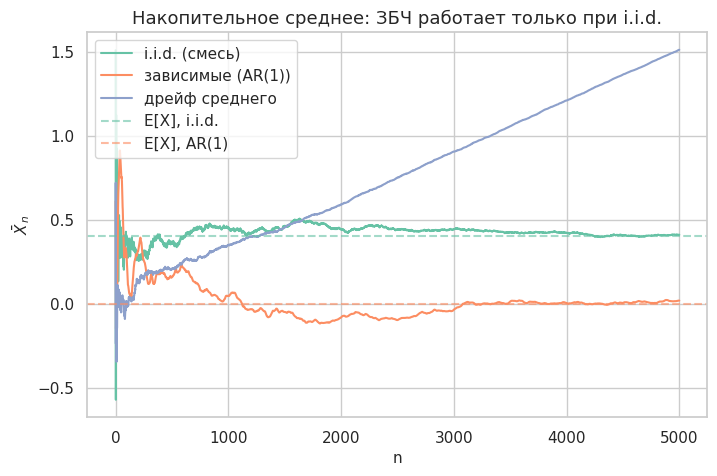

In [ ]:
# Накопительное среднее: показывает, как оценка среднего меняется с ростом выборки
def running_mean(x):
    return np.cumsum(x) / np.arange(1, len(x) + 1)

n = 5000
x_iid_big = sample_mixture(n, rng)
x_dep_big = sample_ar1(n, rng)
x_drift_big = sample_drift(n, rng)

# Истинные матожидания для i.i.d. и AR(1) (для дрифта его просто нет)
true_mean_iid = 0.4 * (-2) + 0.6 * 2       # E X для смеси
true_mean_dep = 0.0                         # стационарное mu AR(1)
# для дрифта "истинного" единого среднего не существует — это и есть суть проблемы

fig, ax = plt.subplots()
ax.plot(running_mean(x_iid_big), label="i.i.d. (смесь)", color=PALETTE[0])
ax.plot(running_mean(x_dep_big), label="зависимые (AR(1))", color=PALETTE[1])
ax.plot(running_mean(x_drift_big), label="дрейф среднего", color=PALETTE[2])

# Горизонтальные линии — куда должно сходиться среднее по ЗБЧ
ax.axhline(true_mean_iid, ls="--", color=PALETTE[0], alpha=0.6, label="E[X], i.i.d.")
ax.axhline(true_mean_dep, ls="--", color=PALETTE[1], alpha=0.6, label="E[X], AR(1)")

ax.set_xlabel("n"); ax.set_ylabel(r"$\bar X_n$")
ax.set_title("Накопительное среднее: ЗБЧ работает только при i.i.d.")
ax.legend()
plt.show()

Несмотря на нарушенную независимость, накопительное среднее для AR(1) всё равно сходится к истинному $\mu$ — просто более "шумно" и медленнее, чем в честном i.i.d.-случае: процесс стационарен (распределение $X_i$ не меняется), корреляция лишь снижает эффективный размер выборки.

Для дрейфа сходиться попросту не к чему: единого $\mathbb E X$ не существует, среднее по построению растёт вместе с $n$.

### 1.4. Центральная предельная теорема

Проверим ЦПТ численно: многократно нагенерируем выборки размера $n$ из
разных распределений, посчитаем $\dfrac{\sqrt n(\bar X_n-\mu)}{\sigma}$ и
посмотрим, насколько это похоже на $\mathcal N(0,1)$. Рассмотрим, в каких случаях ЦПТ не работает.

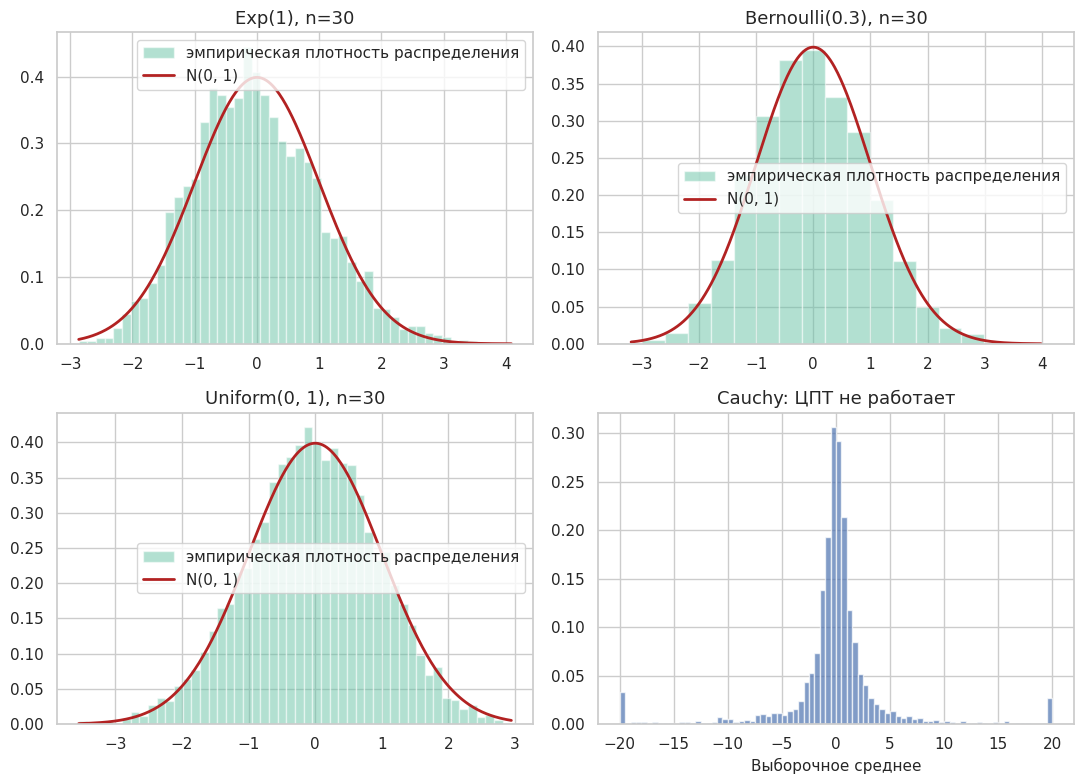

In [ ]:
def simulate_sample_means(sampler, n, n_simulations, rng):
    """Генерирует n_simulations выборок размера n и возвращает их средние."""
    return np.array([
        sampler(n, rng).mean()
        for _ in range(n_simulations)
    ])


def lattice_bins(values, n, sigma):
    """
    Строит бины для решётчатой случайной величины.

    Для Bernoulli выборочное среднее принимает дискретные значения,
    поэтому обычная гистограмма может выглядеть странно. Здесь границы
    бинов располагаются посередине между соседними возможными значениями.
    """
    step = 1 / (sigma * np.sqrt(n))

    return np.arange(
        values.min() - step / 2,
        values.max() + step,
        step
    )


n = 30
n_simulations = 4000

distributions = [
    {
        "name": "Exp(1)",
        "sampler": lambda size, rng: rng.exponential(scale=1, size=size),
        "mean": 1,
        "std": 1,
        "discrete": False,
    },
    {
        "name": "Bernoulli(0.3)",
        "sampler": lambda size, rng: rng.binomial(n=1, p=0.3, size=size),
        "mean": 0.3,
        "std": np.sqrt(0.3 * 0.7),
        "discrete": True,
    },
    {
        "name": "Uniform(0, 1)",
        "sampler": lambda size, rng: rng.uniform(0, 1, size=size),
        "mean": 0.5,
        "std": np.sqrt(1 / 12),
        "discrete": False,
    },
    {
        "name": "Cauchy",
        "sampler": lambda size, rng: rng.standard_cauchy(size=size),
        "mean": None,
        "std": None,
        "discrete": False,
    },
]


fig, axes = plt.subplots(2, 2, figsize=(11, 8))

for ax, dist in zip(axes.ravel(), distributions):

    # Генерируем много выборок и считаем их средние
    sample_means = simulate_sample_means(
        dist["sampler"],
        n=n,
        n_simulations=n_simulations,
        rng=rng,
    )

    # У распределения Коши нет конечных математического ожидания и дисперсии,
    # поэтому стандартная ЦПТ к нему неприменима.
    if dist["name"] == "Cauchy":

        ax.hist(
            np.clip(sample_means, -20, 20),
            bins=80,
            density=True,
            alpha=0.7,
            edgecolor="white",
        )

        ax.set_title("Cauchy: ЦПТ не работает")
        ax.set_xlabel("Выборочное среднее")
        continue

    # Нормировка из ЦПТ:
    # Z_n = sqrt(n) * (X_bar - mu) / sigma
    z = np.sqrt(n) * (sample_means - dist["mean"]) / dist["std"]

    # Для Bernoulli используем бины, согласованные с дискретной решёткой
    if dist["discrete"]:
        bins = lattice_bins(z, n, dist["std"])
    else:
        bins = 50

    plot_hist_vs_density(
        z,
        sps.norm.pdf,
        "N(0, 1)",
        bins=bins,
        title=f'{dist["name"]}, n={n}',
        ax=ax,
        color=PALETTE[0],
    )


plt.tight_layout()
plt.show()

## 2. Оценка параметров распределения

### 2.1. Метод моментов

**Идея метода моментов** состоит в том, чтобы заменить неизвестные теоретические моменты распределения их выборочными аналогами.

Предположим, что случайная величина $X$ имеет распределение, зависящее от неизвестного параметра $\theta$:

$$
X \sim p(x \mid \theta).
$$

Если параметры распределения известны, то можно вычислить его теоретические моменты:

$$
\mathbb E[X], \quad \mathbb E[X^2], \quad \ldots
$$

С другой стороны, по имеющейся выборке

$$
x_1,\ldots,x_n
$$

мы можем посчитать **выборочные моменты**:

$$
\frac{1}{n}\sum_{i=1}^n x_i,\qquad
\frac{1}{n}\sum_{i=1}^n x_i^2,\quad\ldots
$$

По закону больших чисел выборочные моменты при большом $n$ приближаются к соответствующим теоретическим моментам. Поэтому естественная идея — **приравнять их** и использовать полученные уравнения для оценки неизвестных параметров.

Если в распределении есть $m$ неизвестных параметров, то обычно используют первые $m$ моментов и решают систему

$$
\begin{cases}
\widehat{\mu}_1 = \mu_1(\theta_1,\ldots,\theta_m),\\
\widehat{\mu}_2 = \mu_2(\theta_1,\ldots,\theta_m),\\
\vdots\\
\widehat{\mu}_m = \mu_m(\theta_1,\ldots,\theta_m).
\end{cases}
$$

Полученное решение и называется **оценкой параметров методом моментов**.

---

Возьмём распределение $\mathrm{Gamma}(k,\theta)$, для которого

$$
\mathbb E X = k\theta,
\qquad
\mathrm{Var}(X) = k\theta^2.
$$

Здесь неизвестны два параметра: $k$ и $\theta$. Поэтому нам нужны два момента.

В качестве первого момента используем выборочное среднее:

$$
\bar X = \frac{1}{n}\sum_{i=1}^n X_i.
$$

Для второго параметра удобно использовать выборочную дисперсию:

$$
\widehat{\mathrm{Var}}
=
\frac{1}{n}\sum_{i=1}^n (X_i-\bar X)^2.
$$

Приравниваем выборочные и теоретические моменты:

$$
\begin{cases}
\bar X = k\theta,\\
\widehat{\mathrm{Var}} = k\theta^2.
\end{cases}
$$

Теперь решим эту систему относительно $k$ и $\theta$. Из первого уравнения

$$
k = \frac{\bar X}{\theta}.
$$

Подставляя во второе:

$$
\widehat{\mathrm{Var}}
=
\frac{\bar X}{\theta}\theta^2
=
\bar X\theta,
$$

откуда

$$
\boxed{\hat\theta = \frac{\widehat{\mathrm{Var}}}{\bar X}}.
$$

Тогда

$$
\boxed{\hat k = \frac{\bar X}{\hat\theta}
= \frac{\bar X^2}{\widehat{\mathrm{Var}}}}.
$$

Проверим на синтетических данных, что оценки близки к истинным параметрам.


In [ ]:
# Истинные параметры Gamma(k, theta)
k_true, theta_true = 4.0, 2.0
n = 2000

# Генерируем выборку из Gamma-распределения
# shape = k, scale = theta
x = rng.gamma(shape=k_true, scale=theta_true, size=n)

# Выборочный первый момент — среднее
x_bar = x.mean()

# Выборочная дисперсия
# ddof=0 используем, чтобы в знаменателе был именно n
var_hat = x.var(ddof=0)

# Приравниваем теоретические моменты к выборочным:
# x_bar ≈ k * theta
# var_hat ≈ k * theta^2
theta_mom = var_hat / x_bar
k_mom = x_bar**2 / var_hat

# Сравниваем полученные оценки с истинными параметрами
print("Метод моментов:")
print(f"  k_hat     = {k_mom:.3f}   (истинное k = {k_true})")
print(f"  theta_hat = {theta_mom:.3f}   (истинное theta = {theta_true})")

Метод моментов:
  k_hat     = 4.073   (истинное k = 4.0)
  theta_hat = 1.985   (истинное theta = 2.0)


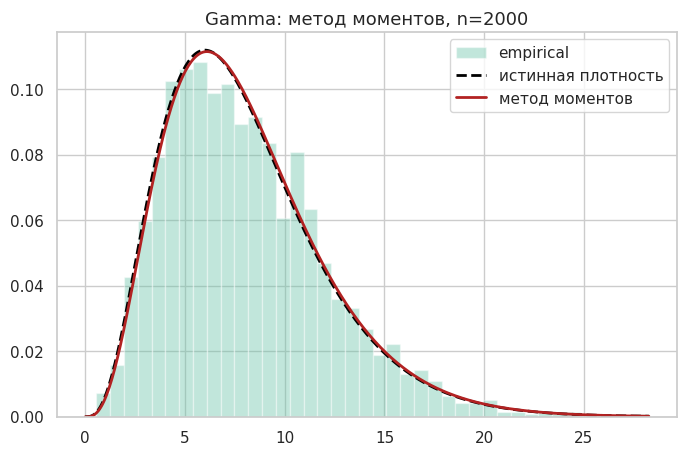

In [ ]:
fig, ax = plt.subplots()

# Плотность Gamma-распределения с параметрами,
# полученными методом моментов
pdf_mom = lambda xs: sps.gamma.pdf(
    xs, a=k_mom, scale=theta_mom
)

# Плотность Gamma-распределения с истинными параметрами,
# из которого была сгенерирована выборка
pdf_true = lambda xs: sps.gamma.pdf(
    xs, a=k_true, scale=theta_true
)

# Сетка значений x, на которой будем строить плотности
xs = np.linspace(0, x.max(), 400)

# Гистограмма выборки.
# density=True нормирует гистограмму так, чтобы её площадь была равна 1,
# поэтому её можно сравнивать с теоретической плотностью
ax.hist(
    x, bins=40, density=True, alpha=0.4,
    color=PALETTE[0], edgecolor="white",
    label="empirical"
)

# Истинная плотность — распределение, из которого была получена выборка
ax.plot(
    xs, pdf_true(xs),
    color="black", lw=2, ls="--",
    label="истинная плотность"
)

# Плотность с параметрами, оценёнными методом моментов.
# Если метод хорошо восстановил параметры, эта кривая
# должна быть близка к истинной плотности
ax.plot(
    xs, pdf_mom(xs),
    color="firebrick", lw=2,
    label="метод моментов"
)

ax.set_title(f"Gamma: метод моментов, n={n}")
ax.legend()
plt.show()

### 2.2. MLE: аналитические значения и `scipy.stats.fit`

Повторим примеры из лекции: MLE для $\mathcal N(\mu,\sigma^2)$ и для
Laplace$(\mu, b)$ имеют явные формулы:

$$\mathcal N(\mu,\sigma^2) \text{:} \qquad \hat\mu_{\mathrm{MLE}} = \bar X, \qquad \hat\sigma^2_{\mathrm{MLE}} = \frac1n\sum_i (X_i-\bar X)^2 \quad \text{(делитель } n\text{, не } n-1\text{!)}$$

$$\text{Laplace}(\mu, b) \text{:} \qquad\hat\mu_{\mathrm{MLE}} = \mathrm{median}(X), \qquad \hat b_{\mathrm{MLE}} = \frac1n\sum_i |X_i - \hat\mu|.$$

Сверим их с тем, что выдаёт `scipy.stats.<dist>.fit`, которое максимизирует
правдоподобие численно.

In [ ]:
def mle_normal_manual(x):
    # Аналитическое решение задачи MLE для Normal(mu, sigma^2):
    # оценка среднего — обычное выборочное среднее
    mu = x.mean()

    # MLE для дисперсии использует делитель n, а не n - 1.
    # Это отличается от стандартной несмещённой оценки дисперсии.
    sigma2 = np.mean((x - mu) ** 2)

    # Параметр распределения scipy.stats.norm — sigma, а не sigma^2
    return mu, np.sqrt(sigma2)


def mle_laplace_manual(x):
    # Для распределения Laplace(mu, b)
    # MLE для параметра положения mu — выборочная медиана
    mu = np.median(x)

    # MLE для параметра масштаба b —
    # среднее абсолютное отклонение от найденной медианы
    b = np.mean(np.abs(x - mu))

    return mu, b


# --- Данные из N(mu, sigma^2) ---
mu_true, sigma_true = 3.0, 1.5
n = 500

# Генерируем выборку из известного распределения
x_norm = rng.normal(mu_true, sigma_true, n)

# Получаем MLE аналитически, используя выведенные ранее формулы
mu_hat, sigma_hat = mle_normal_manual(x_norm)


# ============================================================
# scipy.stats.norm.fit
# ============================================================

# scipy.stats.norm — объект, соответствующий Normal-распределению.
#
# Метод .fit(x) принимает наблюдаемую выборку x и оценивает
# параметры распределения методом максимального правдоподобия (MLE).
#
# Для Normal распределения:
#     norm.fit(x) -> (mu_hat, sigma_hat)
#
# То есть scipy возвращает параметры именно в том порядке,
# в котором они задаются при создании распределения:
#
#     scipy.stats.norm.pdf(x, loc=mu, scale=sigma)
#
# Здесь:
#     loc   = mu
#     scale = sigma
#
# Важно: scipy возвращает sigma, а не sigma^2.
mu_fit, sigma_fit = sps.norm.fit(x_norm)

print("Normal MLE:")
print(f"  аналитические значения: mu={mu_hat:.4f}, sigma={sigma_hat:.4f}")
print(f"  scipy.stats.fit: mu={mu_fit:.4f}, sigma={sigma_fit:.4f}")


# --- Данные из Laplace(mu, b) ---
mu_true_l, b_true = -1.0, 2.0

# Генерируем выборку из распределения Лапласа
x_lap = rng.laplace(mu_true_l, b_true, n)

# Аналитические MLE для параметров Laplace
mu_hat_l, b_hat = mle_laplace_manual(x_lap)


# ============================================================
# scipy.stats.laplace.fit
# ============================================================

# scipy.stats.laplace — объект, соответствующий распределению
# Лапласа.
#
# .fit(x) оценивает параметры распределения по выборке x.
#
# Для Laplace:
#
#     laplace.pdf(x, loc=mu, scale=b)
#
# поэтому результат:
#
#     (mu_fit_l, b_fit)
#
# соответствует:
#     loc   = mu
#     scale = b
#
# То есть scipy использует те же обозначения параметров,
# которые используются в функции плотности.
mu_fit_l, b_fit = sps.laplace.fit(x_lap)

print("\nLaplace MLE:")
print(f"  аналитические значения: mu={mu_hat_l:.4f}, b={b_hat:.4f}")
print(f"  scipy.stats.fit: mu={mu_fit_l:.4f}, b={b_fit:.4f}")

Normal MLE:
  аналитические значения: mu=2.9125, sigma=1.5278
  scipy.stats.fit: mu=2.9125, sigma=1.5278

Laplace MLE:
  аналитические значения: mu=-0.7783, b=1.8919
  scipy.stats.fit: mu=-0.7783, b=1.8919


**Важно:** `scipy.stats.norm.fit` по умолчанию тоже возвращает MLE-оценку
дисперсии со смещённым делителем $n$, а не $(n-1)$. Убедимся в этом на симуляции.

In [ ]:
# Проверяем смещённость sigma^2_MLE (делитель n) относительно S^2 (делитель n-1)
n_small = 5
n_sims = 20000
sigma2_mle_estimates = np.empty(n_sims)
s2_estimates = np.empty(n_sims)

for i in range(n_sims):
    sample = rng.normal(mu_true, sigma_true, n_small)
    sigma2_mle_estimates[i] = np.mean((sample - sample.mean()) ** 2)   # делитель n
    s2_estimates[i] = sample.var(ddof=1)                                # делитель n-1

print(f"Истинная sigma^2      = {sigma_true**2:.4f}")
print(f"E[sigma^2_MLE] (n={n_small}) ≈ {sigma2_mle_estimates.mean():.4f}   <- смещена вниз")
print(f"E[S^2]         (n={n_small}) ≈ {s2_estimates.mean():.4f}   <- несмещена")

Истинная sigma^2      = 2.2500
E[sigma^2_MLE] (n=5) ≈ 1.8071   <- смещена вниз
E[S^2]         (n=5) ≈ 2.2589   <- несмещена


#### 2.2.1. MLE асимптотически несмещена

Мы только что увидели, что при малом $n$ оценка $\hat\sigma^2_{\mathrm{MLE}}$
смещена вниз: $\mathbb E[\hat\sigma^2_{\mathrm{MLE}}] = \frac{n-1}{n}\sigma^2 \ne \sigma^2$.

Но это смещение $\to 0$ при $n \to \infty$, так как $\frac{n-1}{n} \to 1$.
Это общее свойство MLE: даже когда оценка смещена на конечной выборке, при
регулярных условиях она **асимптотически несмещена** и **состоятельна**: $\hat\theta_n \xrightarrow{P} \theta$.

Проверим это численно: посчитаем $\mathrm{Bias}(\hat\sigma^2_{\mathrm{MLE}}) = \mathbb E[\hat\sigma^2_{\mathrm{MLE}}] - \sigma^2$ для растущих $n$ и убедимся, что он стремится к нулю.

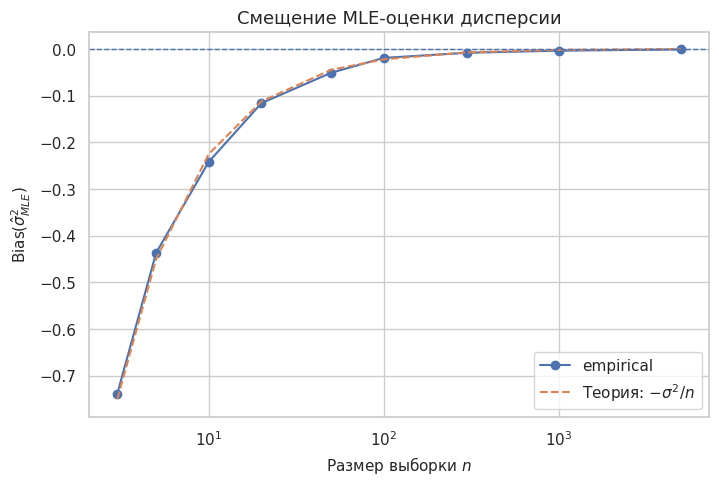

In [ ]:
# Проверяем, как смещение MLE-оценки дисперсии зависит от размера выборки

n_values = [3, 5, 10, 20, 50, 100, 300, 1000, 5000]
n_simulations = 5000

empirical_bias = []

for n in n_values:
    estimates = []

    # Много раз генерируем выборку размера n
    # и каждый раз оцениваем дисперсию методом MLE.
    for _ in range(n_simulations):
        sample = rng.normal(mu_true, sigma_true, size=n)

        # MLE для нормального распределения:
        # делим сумму квадратов отклонений на n, а не на n - 1.
        sigma2_hat = np.mean((sample - sample.mean()) ** 2)

        estimates.append(sigma2_hat)

    # Bias = E[оценка] - истинное значение
    bias = np.mean(estimates) - sigma_true**2
    empirical_bias.append(bias)


theoretical_bias = [
    -sigma_true**2 / n
    for n in n_values
]


# Сравниваем результат симуляции с теоретической формулой
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    n_values,
    empirical_bias,
    "o-",
    label="empirical",
)

ax.plot(
    n_values,
    theoretical_bias,
    "--",
    label=r"Теория: $-\sigma^2/n$",
)

ax.axhline(0, linestyle="--", linewidth=1)

ax.set_xscale("log")
ax.set_xlabel("Размер выборки $n$")
ax.set_ylabel(r"Bias$(\hat{\sigma}^2_{MLE})$")
ax.set_title("Смещение MLE-оценки дисперсии")
ax.legend()

plt.show()


#### 2.2.2. Асимптотическая нормальность MLE

MLE обладает ещё одним свойством, кроме асимптотической несмещённости: при росте $n$ распределение самой оценки приближается к нормальному —

$$
\sqrt n\,(\hat\theta_n-\theta)\ \xrightarrow{d}\ \mathcal N\!\left(0,\ \tfrac{1}{I(\theta)}\right),
$$

где $I(\theta)$ — информация Фишера. По сути это ещё одно проявление ЦПТ из раздела 1 — только теперь нормируем не выборочное среднее, а саму MLE-оценку.

Для $\hat\sigma^2_{\mathrm{MLE}}$ асимптотическая дисперсия равна $2\sigma^4$, поэтому

$$
Z_n = \frac{\sqrt n\,(\hat\sigma^2_{\mathrm{MLE}}-\sigma^2)}{\sqrt2\,\sigma^2}
$$

должна приближаться к $\mathcal N(0,1)$. Проверим это на симуляциях — тем же способом, что и ЦПТ в разделе 1.

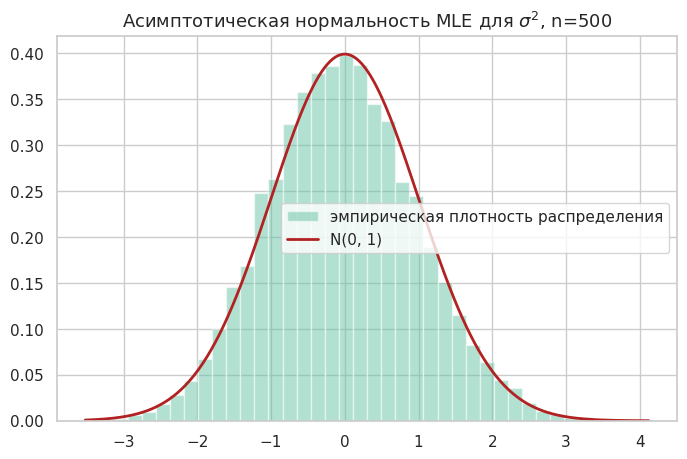

In [ ]:
n_large = 500
n_simulations = 20000

sigma2_hat_samples = np.empty(n_simulations)
for i in range(n_simulations):
    sample = rng.normal(mu_true, sigma_true, size=n_large)
    sigma2_hat_samples[i] = np.mean((sample - sample.mean()) ** 2)

z = np.sqrt(n_large) * (sigma2_hat_samples - sigma_true**2) / (np.sqrt(2) * sigma_true**2)

fig, ax = plt.subplots()
plot_hist_vs_density(
    z, sps.norm.pdf, "N(0, 1)", ax=ax,
    title=f"Асимптотическая нормальность MLE для $\\sigma^2$, n={n_large}"
)
plt.show()

### 2.3. Как выглядит функция правдоподобия

Нарисуем поверхность $\log L(\mu,\sigma^2;\mathcal D)$ для нормальной модели
и отметим на ней MLE-точку.

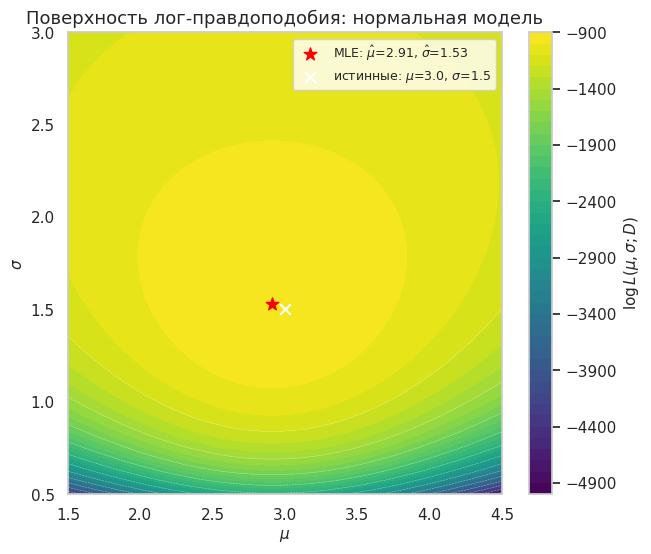

In [ ]:
def normal_loglik(mu, sigma, x):
    return np.sum(sps.norm.logpdf(x, mu, sigma))


mu_grid = np.linspace(mu_true - 1.5, mu_true + 1.5, 100)
sigma_grid = np.linspace(0.5, sigma_true * 2, 100)

MU, SIGMA = np.meshgrid(mu_grid, sigma_grid)

LL = np.array([
    [normal_loglik(m, s, x_norm) for m in mu_grid]
    for s in sigma_grid
])

mu_hat, sigma_hat = mle_normal_manual(x_norm)

fig, ax = plt.subplots(figsize=(7, 6))

cs = ax.contourf(MU, SIGMA, LL, levels=40, cmap="viridis")

ax.contour(MU, SIGMA, LL, levels=15, colors="white", linewidths=0.4, alpha=0.5)

ax.scatter([mu_hat], [sigma_hat], color="red", s=90, marker="*",
    label=(
        f"MLE: $\\hat{{\\mu}}$={mu_hat:.2f}, "
        f"$\\hat{{\\sigma}}$={sigma_hat:.2f}"
    ),
    zorder=5
)

ax.scatter([mu_true], [sigma_true], color="white", s=60, marker="x",
    label=(
        f"истинные: $\\mu$={mu_true}, "
        f"$\\sigma$={sigma_true}"
    ),
    zorder=5
)

fig.colorbar(cs, label=r"$\log L(\mu,\sigma;D)$"
)

ax.set_xlabel(r"$\mu$")
ax.set_ylabel(r"$\sigma$")

ax.set_title("Поверхность лог-правдоподобия: нормальная модель")

ax.legend(loc="upper right", fontsize=9)

plt.show()

### 2.4 MLE vs MAP: что меняет априорное знание?

Пусть мы наблюдаем независимые бинарные события

$$
X_1,\ldots,X_n \overset{iid}{\sim} \operatorname{Bernoulli}(p),
$$

где $p$ — неизвестная вероятность успеха.

Например, $X_i=1$ означает, что пользователь кликнул по рекламе.

Наша задача — оценить $p$ по наблюдаемым данным.

Два подхода:

- **MLE** выбирает параметр, при котором наблюдаемые данные наиболее правдоподобны:

$$
\hat p_{\mathrm{MLE}}
=
\arg\max_p p(D\mid p).
$$

- **MAP** дополнительно учитывает наши априорные представления о параметре:

$$
\hat p_{\mathrm{MAP}}
=
\arg\max_p p(p\mid D)
=
\arg\max_p p(D\mid p)\pi(p).
$$

Посмотрим на практике, насколько сильно prior способен изменить оценку.

#### MLE

Для Bernoulli-распределения

$$
p(X_i\mid p)=p^{X_i}(1-p)^{1-X_i}.
$$

Для всей выборки:

$$
L(p)
=
\prod_{i=1}^n p^{X_i}(1-p)^{1-X_i}.
$$

Если $s=\sum_i X_i$, то

$$
L(p)=p^s(1-p)^{n-s}.
$$

Максимизация этого выражения даёт

$$
\boxed{\hat p_{\mathrm{MLE}}=\frac{s}{n}}.
$$

То есть MLE в данном случае — просто наблюдаемая доля успехов.

In [ ]:
p_true = 0.3
n = 20

x = rng.binomial(1, p_true, size=n)

s = x.sum()

print(f"Размер выборки: {n}")
print(f"Число успехов: {s}")
print(f"Выборочная доля: {x.mean():.3f}")

Размер выборки: 20
Число успехов: 5
Выборочная доля: 0.250


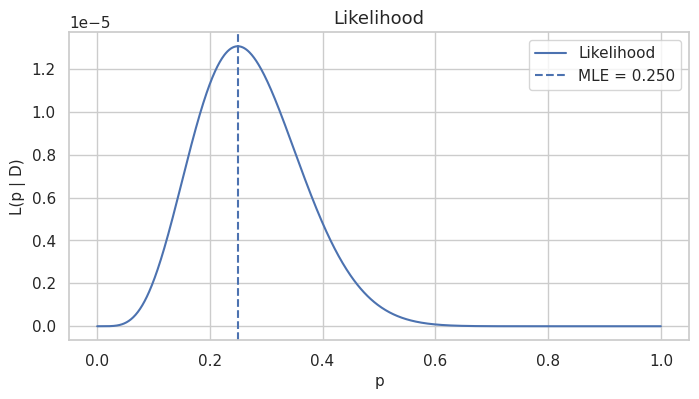

In [ ]:
p_grid = np.linspace(0.001, 0.999, 1000)

likelihood = p_grid**s * (1 - p_grid)**(n - s)

p_mle = s / n

plt.figure(figsize=(8, 4))
plt.plot(p_grid, likelihood, label="Likelihood")
plt.axvline(p_mle, linestyle="--", label=f"MLE = {p_mle:.3f}")

plt.xlabel("p")
plt.ylabel("L(p | D)")
plt.title("Likelihood")
plt.legend()
plt.show()

#### Добавим априорное распределение

Предположим, что до эксперимента мы считаем значения $p$ около $0.5$ более вероятными.

Зададим Beta-prior:

$$
p \sim \operatorname{Beta}(\alpha,\beta).
$$

Его плотность пропорциональна

$$
\pi(p)\propto p^{\alpha-1}(1-p)^{\beta-1}.
$$

Тогда posterior:

$$
p(p\mid D)
\propto
L(p)\pi(p).
$$

В данном случае:

$$
p(p\mid D)
\propto
p^{s+\alpha-1}
(1-p)^{n-s+\beta-1}.
$$

То есть

$$
p\mid D
\sim
\operatorname{Beta}(s+\alpha,n-s+\beta).
$$

MAP — это максимум этой posterior-плотности. А именно

$$
\boxed{
\hat p_{\mathrm{MAP}}
=
\frac{s+\alpha-1}
{n+\alpha+\beta-2}
}
$$

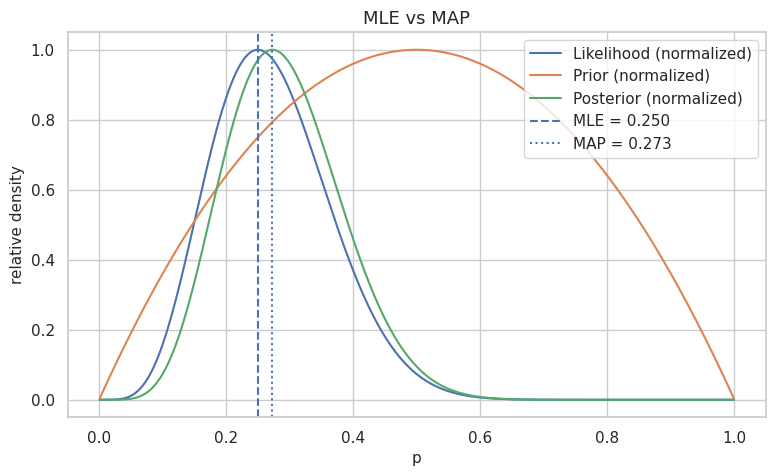

In [ ]:
alpha = 2
beta = 2

prior = sps.beta.pdf(p_grid, alpha, beta)
posterior = sps.beta.pdf(
    p_grid,
    alpha + s,
    beta + n - s
)

p_map = (alpha + s - 1) / (alpha + beta + n - 2)

plt.figure(figsize=(9, 5))

plt.plot(p_grid, likelihood / likelihood.max(),
         label="Likelihood (normalized)")
plt.plot(p_grid, prior / prior.max(),
         label="Prior (normalized)")
plt.plot(p_grid, posterior / posterior.max(),
         label="Posterior (normalized)")

plt.axvline(p_mle, linestyle="--",
            label=f"MLE = {p_mle:.3f}")

plt.axvline(p_map, linestyle=":",
            label=f"MAP = {p_map:.3f}")

plt.xlabel("p")
plt.ylabel("relative density")
plt.title("MLE vs MAP")
plt.legend()
plt.show()

Проверим, как изменится posterior распределение, если усилить prior. То есть если prior распределение более сконцентрировано.

Для $X \sim \operatorname{Beta}(\alpha,\beta)$:

$$
\mathbb{E}[X] = \frac{\alpha}{\alpha+\beta},
$$

$$
\operatorname{Var}(X)
= \frac{\alpha\beta}
{(\alpha+\beta)^2(\alpha+\beta+1)}.
$$

Следовательно, чтобы сохранить матожидание равным 0.5, необходимо равенство $\alpha = \beta$. А при росте $\alpha$ уменьшается дисперсия, следовательно плотность становится более сконцентрированной.

Рассмотрим posterior распределение при разных $\alpha$

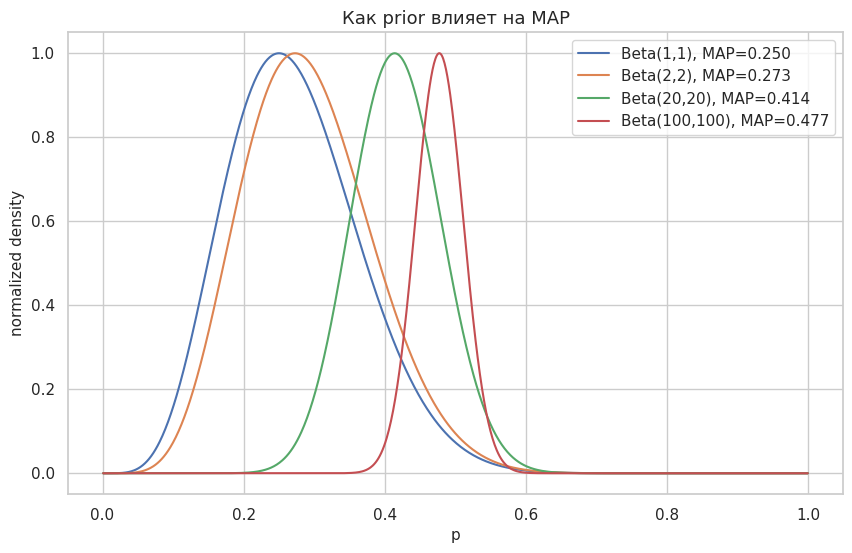

In [ ]:
priors = [
    (1, 1),
    (2, 2),
    (20, 20),
    (100, 100),
]

plt.figure(figsize=(10, 6))


for alpha, beta in priors:
    posterior = sps.beta.pdf(
        p_grid,
        alpha + s,
        beta + n - s
    )

    p_map = (alpha + s - 1) / (alpha + beta + n - 2)

    plt.plot(
        p_grid,
        posterior / posterior.max(),
        label=f"Beta({alpha},{beta}), MAP={p_map:.3f}"
    )

plt.xlabel("p")
plt.ylabel("normalized density")
plt.title("Как prior влияет на MAP")
plt.legend()
plt.show()

#### Что происходит при увеличении количества данных?

Вспомним:

$$
\hat p_{\mathrm{MLE}}=\frac{s}{n}.
$$

Для Beta($\alpha,\beta$)-prior:

$$
\hat p_{\mathrm{MAP}}
=
\frac{s+\alpha-1}
{n+\alpha+\beta-2}.
$$

При фиксированном prior и $n\to\infty$ влияние $\alpha,\beta$ становится всё меньше.

Проверим это экспериментально.

Мы будем генерировать данные из одного и того же распределения, но постепенно увеличивать размер выборки.

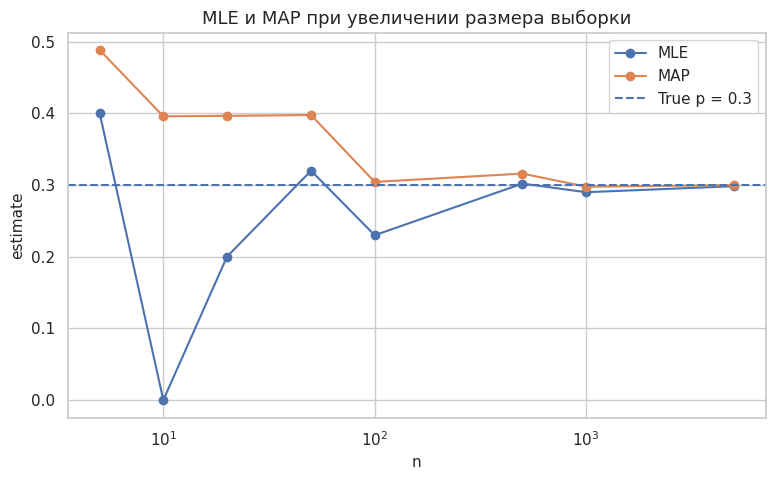

In [ ]:
p_true = 0.3

sample_sizes = np.array([5, 10, 20, 50, 100, 500, 1000, 5000])

alpha = 20
beta = 20

mle_values = []
map_values = []

for n in sample_sizes:
    x = rng.binomial(1, p_true, size=n)
    s = x.sum()
    mle = s / n
    map_ = (s + alpha - 1) / (n + alpha + beta - 2)
    mle_values.append(mle)
    map_values.append(map_)

plt.figure(figsize=(9, 5))

plt.plot(sample_sizes, mle_values, "o-", label="MLE")
plt.plot(sample_sizes, map_values, "o-", label="MAP")

plt.axhline(
    p_true,
    linestyle="--",
    label=f"True p = {p_true}"
)

plt.xscale("log")
plt.xlabel("n")
plt.ylabel("estimate")
plt.title("MLE и MAP при увеличении размера выборки")
plt.legend()
plt.show()

А теперь в качестве prior возьмём равномерное распределение:

$$
p\sim\operatorname{Uniform}(0,1).
$$

Его плотность:

$$
\pi(p)=1,\qquad 0\leq p\leq1.
$$

Тогда

$$
p(p\mid D)
\propto
L(p;D)\pi(p)
=
L(p;D).
$$

Следовательно,

$$
\boxed{
\hat p_{\mathrm{MAP}}=\hat p_{\mathrm{MLE}}
}
$$

при равномерном prior.


### 2.5. Эмпирическая CDF и квантили

$$\hat F_n(t) = \frac1n\sum_i \mathbb I[X_i \le t], \qquad \hat q_\gamma = \inf\{t : \hat F_n(t) \ge \gamma\}.$$

Построим $\hat F_n$ против теоретической $F$ и вычислим несколько
эмпирических квантилей — это понадобится нам позже для бутстрэп-интервалов.

In [ ]:
def ecdf(x):
    x_sorted = np.sort(x)
    y_ecdf = np.arange(1, len(x_sorted) + 1) / len(x_sorted)
    return x_sorted, y_ecdf

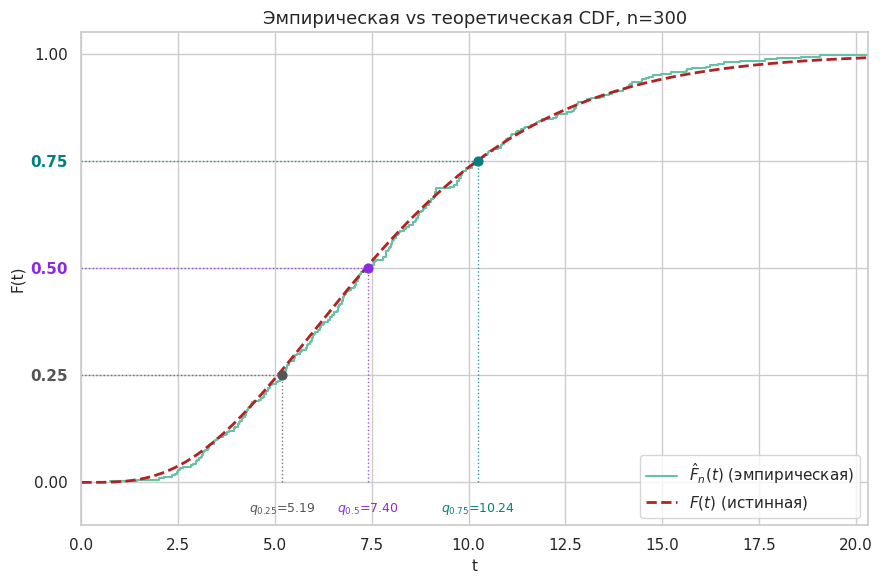

In [ ]:
x_sample = rng.gamma(shape=k_true, scale=theta_true, size=300)
x_sorted, y_ecdf = ecdf(x_sample)

fig, ax = plt.subplots(figsize=(9, 6))
ax.step(x_sorted, y_ecdf, where="post", color=PALETTE[0], lw=1.5,
        label="$\\hat F_n(t)$ (эмпирическая)")
xs = np.linspace(0, x_sample.max(), 400)
ax.plot(xs, sps.gamma.cdf(xs, a=k_true, scale=theta_true), color="firebrick",
        lw=2, ls="--", label="$F(t)$ (истинная)")

# Примеры квантилей для gamma = 0.25, 0.5, 0.75 ---
gammas_demo = [0.25, 0.5, 0.75]
colors_demo = ["#555555", "#8a2be2", "#008080"]

q_emp_list = []
for gamma, c in zip(gammas_demo, colors_demo):
    q_emp = np.quantile(x_sample, gamma, method="lower")
    q_emp_list.append(q_emp)

    # горизонтальная линия на уровне gamma до q_emp
    ax.hlines(gamma, xmin=0, xmax=q_emp, color=c, lw=1, ls=":", alpha=0.8)
    # вертикальная линия от оси X до уровня gamma
    ax.vlines(q_emp, ymin=0, ymax=gamma, color=c, lw=1, ls=":", alpha=0.8)

    ax.scatter([q_emp], [gamma], color=c, s=40, zorder=5)
    ax.annotate(f"$q_{{{gamma}}}$={q_emp:.2f}", xy=(q_emp, 0),
                xytext=(q_emp, -0.07), ha="center", fontsize=9, color=c,
                annotation_clip=False)

# --- Отметки на оси Y на уровнях gamma ---
base_yticks = [0.0, 1.0]
all_yticks = sorted(base_yticks + gammas_demo)
ax.set_yticks(all_yticks)

# красим подписи gamma-отметок в цвет соответствующей линии
for tick_label, y_val in zip(ax.get_yticklabels(), all_yticks):
    if y_val in gammas_demo:
        idx = gammas_demo.index(y_val)
        tick_label.set_color(colors_demo[idx])
        tick_label.set_fontweight("bold")

ax.set_ylim(-0.1, 1.05)
ax.set_xlim(0, x_sample.max())
ax.set_xlabel("t"); ax.set_ylabel("F(t)")
ax.set_title(f"Эмпирическая vs теоретическая CDF, n={len(x_sample)}")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [ ]:
# Эмпирические квантили: numpy delivers q_gamma по определению inf{t : F_n(t) >= gamma}
gammas = [0.05, 0.25, 0.5, 0.75, 0.95]
q_empirical = np.quantile(x_sample, gammas, method="lower")
q_true = sps.gamma.ppf(gammas, a=k_true, scale=theta_true)

quantile_table = pd.DataFrame({
    "gamma": gammas,
    "q_hat (empirical)": q_empirical,
    "q_true (theoretical)": q_true,
})
quantile_table

,gamma,q_hat (empirical),q_true (theoretical)
0,0.05,2.959539,2.732637
1,0.25,5.192383,5.070640
2,0.50,7.396106,7.344121
3,0.75,10.237344,10.218855
4,0.95,14.768746,15.507313


## 3. PLCC, SRCC и корреляционные лоссы на практике

#### Задача

Работаем с **no-reference IQA** (image quality assessment) — задачей из
лекции: модель по изображению (или по признакам, извлечённым из него)
предсказывает число $\hat y_i$ — оценку качества, без доступа к эталонному
изображению. Ground truth — **MOS** (mean opinion score), усреднённая
оценка людей-асессоров по некоторой шкале (например, 1–5).

Формально: есть $n$ объектов, для каждого — вектор признаков $x_i$, истинная
оценка людей $y_i$ (MOS) и предсказание модели $\hat y_i = f_w(x_i)$.


#### Определения

**PLCC (Pearson Linear Correlation Coefficient)** — обычная корреляция
Пирсона, применённая к паре (предсказание, MOS):

$$
\mathrm{PLCC} = r_{\hat y, y} = \frac{\widehat{\mathrm{Cov}}(\hat y, y)}{S_{\hat y}\, S_y}
= \frac{\sum_i (\hat y_i - \bar{\hat y})(y_i - \bar y)}{\sqrt{\sum_i(\hat y_i - \bar{\hat y})^2}\sqrt{\sum_i (y_i - \bar y)^2}}.
$$

PLCC измеряет **линейное согласие**: она равна $\pm1$ тогда и только
тогда, когда $\hat y_i = a\, y_i + b$ точно для всех $i$ (аффинная
зависимость). Она инвариантна к сдвигу и масштабу, но чувствительна
к нелинейности связи.

**SRCC (Spearman Rank Correlation Coefficient)** — та же формула Пирсона,
но применённая не к самим значениям, а к их **рангам**:

$$
R_i = \mathrm{rank}(\hat y_i), \quad M_i = \mathrm{rank}(y_i), \qquad
\mathrm{SRCC} = r_{R, M}.
$$

SRCC измеряет **согласие в порядке**: она равна $\pm 1$ тогда и только
тогда, когда $\hat y$ и $y$ связаны произвольной **монотонной** (не
обязательно линейной) функцией. Она полностью инвариантна к любой
монотонной трансформации шкалы предсказаний — то есть не важно, насколько
"кривая" эта шкала, лишь бы порядок сохранялся.



### 3.1 Применение на практике
Рассмотрим ситуацию, в которой примемнение MSE невозможно.

Для этого рассмотрим 3 типа признаков.
1. Немного зашумленное афинное преобразование от изначального MOS
2. Нелинейное преобразование от изначального MOS, но зато почти не зашумленное
3. Очень зашумленный MOS

Так как все варианты кроме третьего находятся в совершенно других диапазонах относительно MOS, мы ожидаем, что MSE даст наилучшее соответствие 3 варианту. Но на практике же гораздо эффективнее выбрать вариант 2.

Посмотрим на синтетических данных:

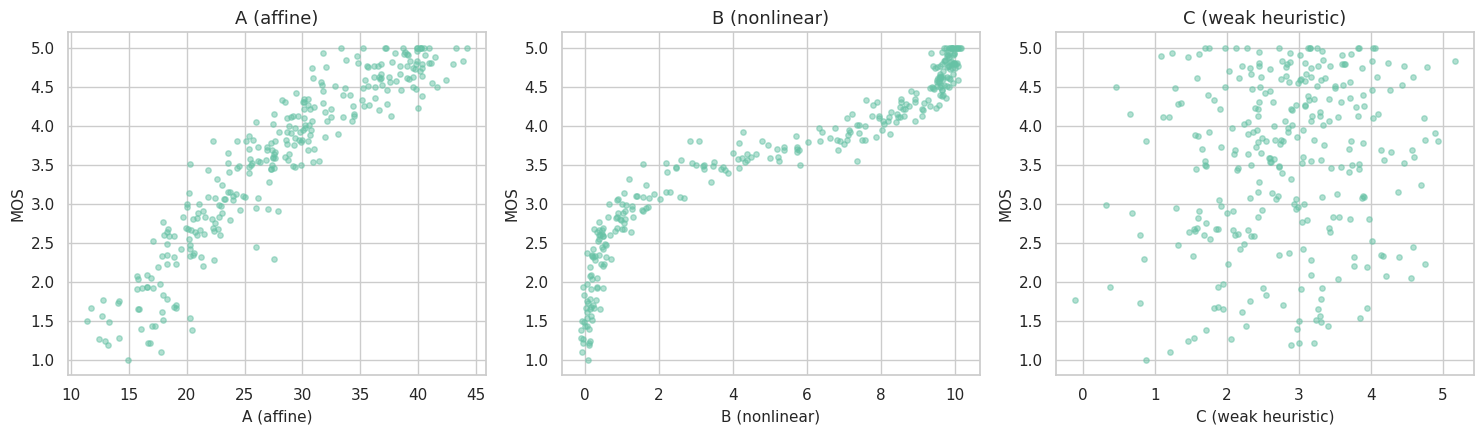

In [ ]:
n = 300
q = rng.uniform(0, 1, n)   # скрытое истинное качество

# MOS: шкала 1-5, как в типичных subjective-исследованиях
mos = np.clip(1 + 4 * q**0.6 + rng.normal(0, 0.15, n), 1, 5)

# Предиктор A: affine — линейно связан с качеством, но шумный, шкала ~15-40
pred_A = 15 + 25 * q + rng.normal(0, 2.5, n)

# Предиктор B: nonlinear — сильно нелинейная, но почти идеально
# монотонная связь с качеством (насыщающаяся сигмоида), малый шум, шкала 0-10
pred_B = 10 / (1 + np.exp(-10 * (q - 0.5))) + rng.normal(0, 0.15, n)

# Предиктор C: "слабый эвристический скор" — почти не несёт сигнала о качестве,
# но случайно находится в той же шкале, что и MOS (1-5)
pred_C = 2.5 + 0.5 * q + rng.normal(0, 1.0, n)

predictors = {"A (affine)": pred_A, "B (nonlinear)": pred_B, "C (weak heuristic)": pred_C}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (name, pred) in zip(axes, predictors.items()):
    ax.scatter(pred, mos, alpha=0.5, s=15, color=PALETTE[0])
    ax.set_xlabel(name); ax.set_ylabel("MOS")
    ax.set_title(name)
plt.tight_layout()
plt.show()

### 3.2. Почему MSE здесь бесполезна

Посчитаем `MSE(predictor, MOS)` напрямую — так, как сделал бы человек,
не задумываясь о шкалах.

In [ ]:
mse_table = pd.DataFrame({
    "predictor": list(predictors.keys()),
    "raw MSE vs MOS": [np.mean((pred - mos) ** 2) for pred in predictors.values()],
    "predictor scale (min, max)": [f"[{pred.min():.1f}, {pred.max():.1f}]" for pred in predictors.values()],
})
mse_table.sort_values("raw MSE vs MOS")

,predictor,raw MSE vs MOS,"predictor scale (min, max)"
2,C (weak heuristic),2.279364,"[-0.1, 5.2]"
1,B (nonlinear),11.524986,"[-0.1, 10.2]"
0,A (affine),648.289057,"[11.4, 44.2]"


**Что произошло:** по сырой MSE предиктор **C выигрывает** — просто потому,
что случайно живёт в той же шкале, что и MOS (1–5), хотя почти не несёт
информации о реальном качестве. Предикторы A и B, один из которых (B)
на самом деле почти идеально отслеживает истинное качество, штрафуются
MSE за банальное несовпадение единиц измерения, а не за реальную
неточность.

А теперь посмотрим на PLCC и SRCC метрики

In [ ]:
metric_table = pd.DataFrame({
    "predictor": list(predictors.keys()),
    "PLCC": [sps.pearsonr(pred, mos)[0] for pred in predictors.values()],
    "SRCC": [sps.spearmanr(pred, mos)[0] for pred in predictors.values()],
}).sort_values("SRCC", ascending=False)
metric_table

,predictor,PLCC,SRCC
1,B (nonlinear),0.938985,0.981487
0,A (affine),0.930147,0.946443
2,C (weak heuristic),0.159503,0.146456


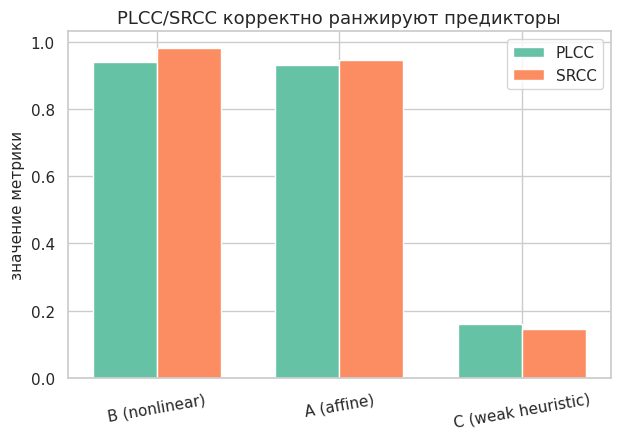

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4.5))
x_pos = np.arange(len(metric_table))
width = 0.35
ax.bar(x_pos - width/2, metric_table["PLCC"], width, label="PLCC", color=PALETTE[0])
ax.bar(x_pos + width/2, metric_table["SRCC"], width, label="SRCC", color=PALETTE[1])
ax.set_xticks(x_pos)
ax.set_xticklabels(metric_table["predictor"], rotation=10)
ax.set_ylabel("значение метрики")
ax.set_title("PLCC/SRCC корректно ранжируют предикторы")
ax.legend()
plt.show()

**Что теперь видно:** и PLCC, и особенно SRCC (за счёт инвариантности к
монотонным преобразованиям) правильно ставят **B на первое место** — это
единственный предиктор с почти идеальной (хотя и нелинейной) связью с
истинным качеством. C оказывается на последнем месте, как и должно быть.
Ни PLCC, ни SRCC не заботятся о том, что шкалы у A, B, C разные — это и
есть их главное практическое преимущество перед MSE в задаче сравнения
разнородных метрик.

## 4. Доверительные интервалы

Мы умеем получать оценку неизвестного параметра по выборке. Но насколько можно доверять этой оценке?

Например, мы получили

$$\hat{\mu} = 10.3.$$

Что это означает? Насколько далеко истинное значение $\mu$ может находиться от нашей оценки?

Один из способов ответить на этот вопрос — построить **доверительный интервал**.

In [ ]:
# Истинные параметры
mu_true = 10
sigma_true = 3

# Размер выборки
n = 20

# Получаем одну выборку
x = rng.normal(mu_true, sigma_true, size=n)

print(f"Истинное μ = {mu_true}")
print(f"Выборочное среднее = {x.mean():.3f}")
print(f"Выборочное стандартное отклонение = {x.std(ddof=1):.3f}")

Истинное μ = 10
Выборочное среднее = 10.700
Выборочное стандартное отклонение = 2.596


Для нормальной выборки в лекции используется статистика

$$T = \frac{X - \mu}{S / \sqrt{n}} \sim t_{n-1}.$$

Отсюда

$$\mu \in \bar{X} \pm t_{n-1, 1-\alpha/2} \frac{S}{\sqrt{n}}.$$

In [ ]:
alpha = 0.05

x_bar = x.mean()
s = x.std(ddof=1)

df = n - 1
t_critical = sps.t.ppf(1 - alpha / 2, df)

se = s / np.sqrt(n)

ci_low = x_bar - t_critical * se
ci_high = x_bar + t_critical * se

print(f"95% доверительный интервал: [{ci_low:.3f}, {ci_high:.3f}]")
print(f"Истинное μ = {mu_true}")

95% доверительный интервал: [9.485, 11.915]
Истинное μ = 10


По большому числу выборок проверим реальную вероятность попадания целивой величины в интервал:

In [ ]:
n_experiments = 1000

intervals = []
covered = []

for _ in range(n_experiments):
    x = rng.normal(mu_true, sigma_true, size=n)

    x_bar = x.mean()
    s = x.std(ddof=1)

    t_critical = sps.t.ppf(1 - alpha / 2, df=n-1)
    margin = t_critical * s / np.sqrt(n)

    low = x_bar - margin
    high = x_bar + margin

    intervals.append((low, high))
    covered.append(low <= mu_true <= high)

intervals = np.array(intervals)
covered = np.array(covered)

print(f"Доля интервалов, накрывших μ: {covered.mean():.3f}")

Доля интервалов, накрывших μ: 0.955


In [ ]:
sample_sizes = [5, 10, 20, 50, 100, 500]
n_experiments = 2000

results = []

for n in sample_sizes:
    widths = []
    covered = []

    for _ in range(n_experiments):
        x = rng.normal(mu_true, sigma_true, size=n)

        x_bar = x.mean()
        s = x.std(ddof=1)

        t_critical = sps.t.ppf(1 - alpha / 2, df=n - 1)
        margin = t_critical * s / np.sqrt(n)

        low = x_bar - margin
        high = x_bar + margin

        widths.append(high - low)
        covered.append(low <= mu_true <= high)

    results.append({
        "n": n,
        "coverage": np.mean(covered),
        "mean_width": np.mean(widths)
    })

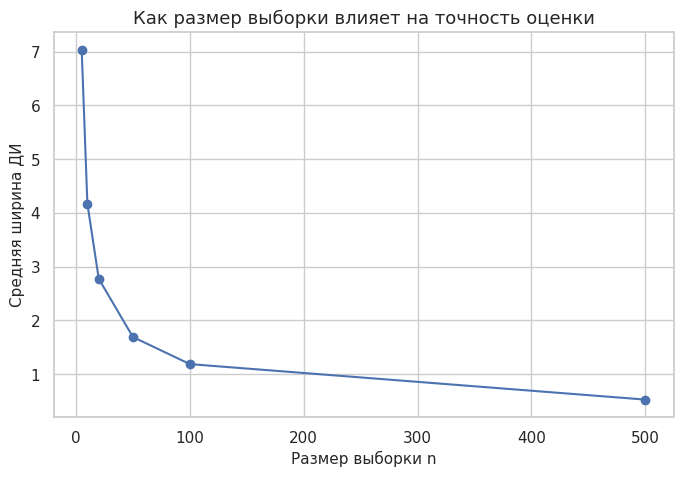

In [ ]:
widths = [r["mean_width"] for r in results]
ns = [r["n"] for r in results]

plt.figure(figsize=(8, 5))

plt.plot(ns, widths, 'o-')

plt.xlabel("Размер выборки n")
plt.ylabel("Средняя ширина ДИ")
plt.title("Как размер выборки влияет на точность оценки")

plt.show()

### Доверительный интервал для параметра экспоненциального распределения

Рассмотрим выборку

$$
X_1,\ldots,X_n \overset{iid}{\sim} \operatorname{Exp}(\lambda).
$$

Плотность экспоненциального распределения:

$$
f(x|\lambda)=\lambda e^{-\lambda x}, \qquad x\geq0.
$$

Пусть истинное значение параметра неизвестно.

Для экспоненциального распределения справедливо:

$$
2\lambda\sum_{i=1}^n X_i\sim\chi^2_{2n}.
$$

Поэтому для уровня доверия $1-\alpha$:

$$
\boxed{
\frac{\chi^2_{2n,\alpha/2}}{2S}
\leq
\lambda
\leq
\frac{\chi^2_{2n,1-\alpha/2}}{2S}
}
$$
где

$$
S=\sum_{i=1}^n X_i.
$$

Получим этот интервал для одной сгенерированной выборки.

In [ ]:
import numpy as np
import scipy.stats as sps
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

lambda_true = 2
n = 20
alpha = 0.05

x = rng.exponential(scale=1 / lambda_true, size=n)

S = np.sum(x)

chi2_low = sps.chi2.ppf(alpha / 2, df=2 * n)
chi2_high = sps.chi2.ppf(1 - alpha / 2, df=2 * n)

lambda_low = chi2_low / (2 * S)
lambda_high = chi2_high / (2 * S)

print(f"Истинное λ = {lambda_true}")
print(f"95% ДИ: [{lambda_low:.3f}, {lambda_high:.3f}]")

Истинное λ = 2
95% ДИ: [1.164, 2.827]


In [ ]:
n_experiments = 5000

covered = []
intervals = []

for _ in range(n_experiments):
    x = rng.exponential(scale=1 / lambda_true, size=n)
    S = np.sum(x)

    low = sps.chi2.ppf(alpha / 2, df=2*n) / (2*S)
    high = sps.chi2.ppf(1 - alpha / 2, df=2*n) / (2*S)

    intervals.append((low, high))
    covered.append(low <= lambda_true <= high)

covered = np.array(covered)
intervals = np.array(intervals)

print(f"Номинальное покрытие: {1-alpha:.3f}")
print(f"Фактическое покрытие: {covered.mean():.3f}")

Номинальное покрытие: 0.950
Фактическое покрытие: 0.953


### Предсказательный интервал

Пусть

$$
X_1,\ldots,X_n \overset{\text{i.i.d.}}{\sim}\mathcal N(\mu,\sigma^2),
$$

и мы хотим предсказать значение нового независимого наблюдения

$$
X_{n+1}\sim\mathcal N(\mu,\sigma^2).
$$

В отличие от доверительного интервала, нас интересует не неизвестный параметр $\mu$, а **конкретная будущая случайная величина** $X_{n+1}$.

Если бы $\mu$ и $\sigma^2$ были известны, то всё было бы просто:

$$
X_{n+1}\sim\mathcal N(\mu,\sigma^2),
$$

и интервал с уровнем доверия $1-\alpha$ имел бы вид

$$
\mu\pm z_{1-\alpha/2}\sigma.
$$

Но на практике $\mu$ и $\sigma$ неизвестны. Мы заменяем $\mu$ и $\sigma$ их оценками $\bar X$ и $S$.

При этом нужно учитывать **две составляющие неопределённости**.

Запишем ошибку предсказания:

$$
X_{n+1}-\bar X
=
(X_{n+1}-\mu)-(\bar X-\mu).
$$

Первая часть

$$
X_{n+1}-\mu
$$

описывает случайность самого нового наблюдения.

Вторая часть

$$
\bar X-\mu
$$

возникает из-за того, что $\mu$ нам неизвестно и мы оцениваем его по конечной выборке.

Поскольку $X_{n+1}$ независимо от $\bar X$ и

$$
\operatorname{Var}(X_{n+1}-\mu)=\sigma^2,
\qquad
\operatorname{Var}(\bar X-\mu)=\frac{\sigma^2}{n},
$$

получаем

$$
\operatorname{Var}(X_{n+1}-\bar X)
=
\sigma^2+\frac{\sigma^2}{n}
=
\sigma^2\left(1+\frac1n\right).
$$

Поэтому естественная стандартизированная статистика имеет вид

$$
\frac{X_{n+1}-\bar X}
{S\sqrt{1+\frac1n}}.
$$

Для нормальной выборки она имеет распределение Стьюдента с $n-1$ степенями свободы:

$$
\boxed{
\frac{X_{n+1}-\bar X}
{S\sqrt{1+\frac1n}}
\sim t_{n-1}
}.
$$

Отсюда получаем предсказательный интервал уровня $1-\alpha$:

$$
\boxed{
X_{n+1}
\in
\bar X
\pm
t_{n-1,\,1-\alpha/2}
S\sqrt{1+\frac1n}
}.
$$

Таким образом, предсказательный интервал шире доверительного интервала для $\mu$:

$$
\underbrace{
\bar X\pm
t_{n-1,\,1-\alpha/2}\frac{S}{\sqrt n}
}_{\text{доверительный интервал для }\mu}
$$

и

$$
\underbrace{
\bar X\pm
t_{n-1,\,1-\alpha/2}
S\sqrt{1+\frac1n}
}_{\text{предсказательный интервал для }X_{n+1}}.
$$

Причина принципиальна: **доверительный интервал учитывает неопределённость оценки $\mu$, а предсказательный интервал дополнительно учитывает случайность самого будущего наблюдения**.

При больших $n$ неопределённость оценки среднего становится малой,

$$
\frac1n\to0,
$$

но неопределённость нового наблюдения никуда не исчезает. Поэтому даже при очень большой выборке предсказательный интервал стремится к

$$
\mu\pm z_{1-\alpha/2}\sigma,
$$

а не сжимается до одной точки.


Проверим вероятность попадания нового измерения в предсказательный интервал:

In [ ]:
# Истинные параметры
mu_true = 170
sigma_true = 10

# Параметры эксперимента
n = 30
n_sims = 10_000
alpha = 0.05

covered = np.zeros(n_sims, dtype=bool)

for i in range(n_sims):
    # Генерируем обучающую выборку
    sample = rng.normal(mu_true, sigma_true, size=n)

    # Оценки параметров
    x_bar = np.mean(sample)
    s = np.std(sample, ddof=1)

    # Критическое значение t-распределения
    t_crit = sps.t.ppf(1 - alpha / 2, df=n - 1)

    # 95% предсказательный интервал
    margin = t_crit * s * np.sqrt(1 + 1 / n)
    pi_left = x_bar - margin
    pi_right = x_bar + margin

    # Новое независимое наблюдение
    x_new = rng.normal(mu_true, sigma_true)

    # Попало ли новое наблюдение в интервал?
    covered[i] = pi_left <= x_new <= pi_right

coverage = np.mean(covered)

print(f"Номинальный уровень: {1 - alpha:.1%}")
print(f"Эмпирическое покрытие: {coverage:.1%}")

Номинальный уровень: 95.0%
Эмпирическое покрытие: 94.6%


## 6. Проверка статистических гипотез

До сих пор мы в основном занимались **оцениванием параметров** распределения по выборке. Но во многих задачах нас интересует другой вопрос: **согласуются ли наблюдаемые данные с некоторым предположением о распределении или его параметрах?**

Например:

* можно ли считать среднее значение равным заданному числу?
* отличаются ли средние двух групп?
* есть ли статистически значимая зависимость между двумя величинами?
* можно ли считать, что данные получены из некоторого заданного распределения?

Для этого формулируют **статистические гипотезы**.

#### Простая и сложная гипотеза

**Простая гипотеза** полностью задаёт распределение данных. Например,

$$
H_0: X_i \sim \mathcal N(0,1).
$$

Здесь полностью известны и математическое ожидание, и дисперсия.

**Сложная гипотеза** задаёт семейство возможных распределений, то есть оставляет неизвестными один или несколько параметров. Например,

$$
H_0: X_i \sim \mathcal N(\mu,1),
$$

где $\mu$ неизвестно.

Обычно мы рассматриваем две конкурирующие гипотезы:

$$
H_0 \quad\text{— нулевая гипотеза},
$$

$$
H_1 \quad\text{— альтернативная гипотеза}.
$$

#### Идея проверки

Предположим, что **нулевая гипотеза верна**. Тогда мы знаем, из какого распределения получены данные (или, в случае сложной гипотезы, каким образом это распределение зависит от неизвестных параметров).

Выберем некоторую **статистику критерия** $T(X)$, которая позволяет измерять, насколько наблюдаемые данные согласуются с $H_0$.

Если $H_0$ верна, то статистика $T$ имеет некоторое распределение. Оно называется **нулевым распределением**:

$$
T \mid H_0 \sim F_0.
$$

Теперь можем спросить: **насколько необычным является наблюдаемое значение статистики $T_{\mathrm{obs}}$ при условии, что $H_0$ верна?**

Если наблюдаемое значение оказывается очень маловероятным при нулевом распределении, это является свидетельством против $H_0$, и мы **отвергаем нулевую гипотезу**.



### 6.1 t-test
Рассмотрим простую задачу. Пусть у нас есть выборка

$$
X_1,\ldots,X_n \sim \mathcal N(\mu,\sigma^2),
$$

где $\mu$ и $\sigma^2$ неизвестны.

Хотим проверить гипотезу о том, что математическое ожидание равно некоторому заданному значению $\mu_0$:

$$
H_0:\ \mu=\mu_0.
$$

В качестве альтернативы рассмотрим

$$
H_1:\ \mu\ne\mu_0.
$$

Как проверить такую гипотезу?

Мы уже знаем, что среднее выборки

$$
\bar X = \frac{1}{n}\sum_{i=1}^n X_i
$$

является оценкой $\mu$. Поэтому естественно посмотреть, **насколько далеко наблюдаемое среднее $\bar X$ находится от предполагаемого значения $\mu_0$**.

Но просто разности $\bar X-\mu_0$ недостаточно: отклонение, например, на $0.5$ может быть большим для одной выборки и совершенно нормальным для другой.

Поэтому нормируем это отклонение на стандартную ошибку среднего:

$$
T =
\frac{\bar X-\mu_0}{S/\sqrt n},
$$

где

$$
S^2 = \frac{1}{n-1}\sum_{i=1}^n (X_i-\bar X)^2.
$$

Эта величина называется **t-статистикой**.

Теперь возвращаемся к общей схеме проверки гипотез.

Если $H_0$ верна, то $\mu=\mu_0$, и для нормальной выборки статистика $T$ имеет известное распределение:

$$
T\mid H_0 \sim t_{n-1}.
$$

Это и есть наше **нулевое распределение**.

Поэтому вместо вопроса «насколько вероятна именно эта выборка?» мы теперь можем задать корректный вопрос:

> Насколько необычным является наблюдаемое значение $T_{\mathrm{obs}}$, если нулевая гипотеза действительно верна?


Продемонстрируем на примере:

In [ ]:
mu_true = 10.5
sigma_true = 2.0

n = 20
mu_0 = 10.0

x = rng.normal(mu_true, sigma_true, size=n)

print(f"n = {n}")
print(f"Выборочное среднее = {x.mean():.3f}")
print(f"Выборочное стандартное отклонение = {x.std(ddof=1):.3f}")

n = 20
Выборочное среднее = 11.066
Выборочное стандартное отклонение = 2.194


Посчитаем значение t-статистики для нашей выборки

In [ ]:
x_mean = x.mean()
x_std = x.std(ddof=1)

t_obs = (x_mean - mu_0) / (x_std / np.sqrt(n))

print(f"t-statistic = {t_obs:.3f}")

t-statistic = 2.173


Мы знаем, какое распределение у этой статистики при условии истинности $H_0$

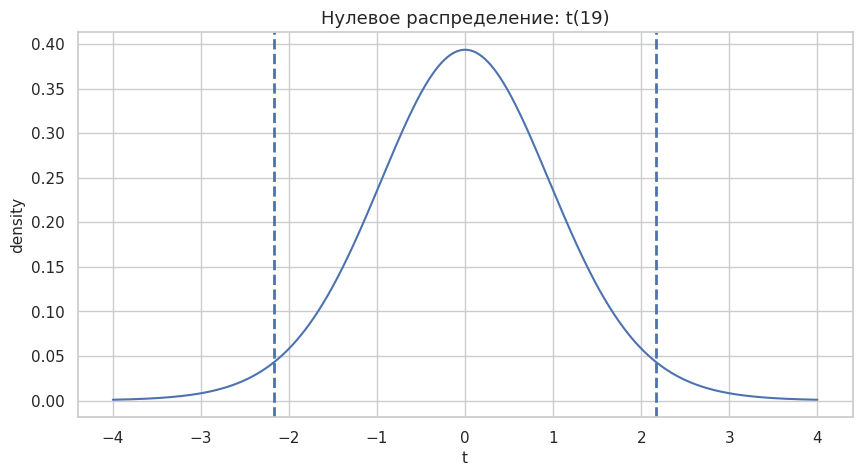

In [ ]:
df = n - 1

t_grid = np.linspace(-4, 4, 1000)
pdf = sps.t.pdf(t_grid, df=df)

plt.figure(figsize=(10, 5))

plt.plot(t_grid, pdf)

plt.axvline(t_obs, linestyle="--", linewidth=2)
plt.axvline(-t_obs, linestyle="--", linewidth=2)

plt.xlabel("t")
plt.ylabel("density")
plt.title(f"Нулевое распределение: t({df})")

plt.show()

На графике видно значение $T_{\text{obs}}$ (реализация t-статистики).

Нас интересует, с какой вероятностью могло произойти такое или еще более сильное отклонение. (`p-value`)

$$
|T|\geq |T_{\text{obs}}|.
$$

Если наблюдаемое значение находится далеко в хвосте нулевого распределения, оно плохо согласуется с $H_0$.

In [ ]:
p_value = 2 * sps.t.sf(np.abs(t_obs), df=df)

print(f"t-statistic = {t_obs:.4f}")
print(f"p-value     = {p_value:.4f}")

t-statistic = 2.1728
p-value     = 0.0427


#### Решение по p-value

Заранее выбираем уровень значимости, например

$$
\alpha = 0.05.
$$

Правило:

$$
p\leq\alpha
\quad\Longrightarrow\quad
\text{отвергаем }H_0.
$$

Иначе:

$$
p>\alpha
\quad\Longrightarrow\quad
\text{не отвергаем }H_0.
$$

Обратите внимание на формулировку:

**мы не принимаем $H_0$**, а лишь не нашли достаточных оснований для её отвержения.


$\alpha$ -- ошибка первого рода. То есть вероятность отклонить $H_0$, при условии истинности $H_0$.

#### Критическая область и ошибка I рода

Можно принимать решение не через $p$-value, а непосредственно через критическое значение.

Для двустороннего критерия уровня $\alpha$:

$$
|T| > t_{n-1,1-\alpha/2}.
$$

Найдём критические значения для нашего эксперимента.

In [ ]:
t_critical = sps.t.ppf(1 - alpha / 2, df=df)

print(f"Критические значения: ±{t_critical:.4f}")
print(f"Наблюдаемое значение: {t_obs:.4f}")

if abs(t_obs) > t_critical:
    print("T попало в критическую область → отвергаем H0")
else:
    print("T не попало в критическую область → не отвергаем H0")

Критические значения: ±2.0930
Наблюдаемое значение: 2.1728
T попало в критическую область → отвергаем H0


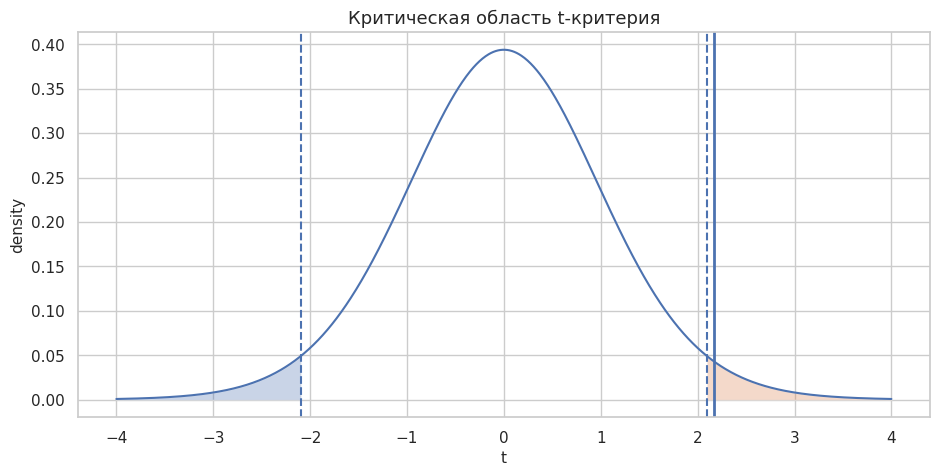

In [ ]:
plt.figure(figsize=(11, 5))

plt.plot(t_grid, pdf)

left_tail = t_grid <= -t_critical
right_tail = t_grid >= t_critical

plt.fill_between(
    t_grid[left_tail],
    pdf[left_tail],
    alpha=0.3
)

plt.fill_between(
    t_grid[right_tail],
    pdf[right_tail],
    alpha=0.3
)

plt.axvline(-t_critical, linestyle="--")
plt.axvline(t_critical, linestyle="--")

plt.axvline(t_obs, linestyle="-", linewidth=2)

plt.xlabel("t")
plt.ylabel("density")
plt.title("Критическая область t-критерия")

plt.show()

#### Проверяем уровень значимости экспериментально

Мы утверждаем, что критерий уровня $\alpha=0.05$ имеет вероятность ошибки I рода не больше 5%:

$$
P_{H_0}(\text{отвергнуть }H_0)\approx 0.05.
$$

Проверим это экспериментально.

Сделаем много экспериментов, в каждом из которых $H_0$ заведомо верна:

$$
X_i\sim\mathcal N(\mu_0,\sigma^2).
$$

Каждый раз применим наш t-критерий и посчитаем долю случаев, когда он ошибочно отвергнул $H_0$.

In [ ]:
n_experiments = 10_000
n = 20
mu_0 = 10
sigma = 2
alpha = 0.05

rejected = np.zeros(n_experiments, dtype=bool)

for i in range(n_experiments):
    x = rng.normal(mu_0, sigma, size=n)

    t_obs = (x.mean() - mu_0) / (
        x.std(ddof=1) / np.sqrt(n)
    )

    p_value = 2 * sps.t.sf(
        np.abs(t_obs),
        df=n - 1
    )

    rejected[i] = p_value <= alpha

error_type_I = rejected.mean()

print(f"Количество экспериментов: {n_experiments}")
print(f"Уровень значимости α:     {alpha}")
print(f"Доля ложных отвержений:   {error_type_I:.4f}")

Количество экспериментов: 10000
Уровень значимости α:     0.05
Доля ложных отвержений:   0.0467


#### Ошибка II рода

Теперь изменим ситуацию.

Пусть $H_0$ уже **неверна**:

$$
\mu\neq\mu_0.
$$

Например,

$$
\mu=10.5,\qquad \mu_0=10.
$$

Если критерий всё равно не отвергнет $H_0$, мы совершим **ошибку II рода**.

Её вероятность обозначается $\beta$:

$$
\beta=P(\text{не отвергнуть }H_0\mid H_1).
$$

А величина

$$
1-\beta
$$

называется **мощностью критерия**.

То есть мощность — это вероятность обнаружить реальный эффект заданного размера.

In [ ]:
def estimate_power(mu_true, mu_0, sigma, n, alpha=0.05,
                   n_experiments=5000):

    rejected = 0

    for _ in range(n_experiments):
        x = rng.normal(mu_true, sigma, size=n)

        t_obs = (x.mean() - mu_0) / (
            x.std(ddof=1) / np.sqrt(n)
        )

        p_value = 2 * sps.t.sf(
            np.abs(t_obs),
            df=n - 1
        )

        rejected += p_value <= alpha

    return rejected / n_experiments


power = estimate_power(
    mu_true=10.5,
    mu_0=10,
    sigma=2,
    n=20
)

print(f"Оценка мощности: {power:.3f}")
print(f"Оценка β:        {1 - power:.3f}")

Оценка мощности: 0.185
Оценка β:        0.815


#### От чего зависит мощность?

Интуитивно критерий легче обнаруживает эффект, если:

- эффект $\lvert\mu-\mu_0\rvert$ больше;
- размер выборки $n$ больше;
- шум $\sigma$ меньше.

Проверим влияние размера выборки.

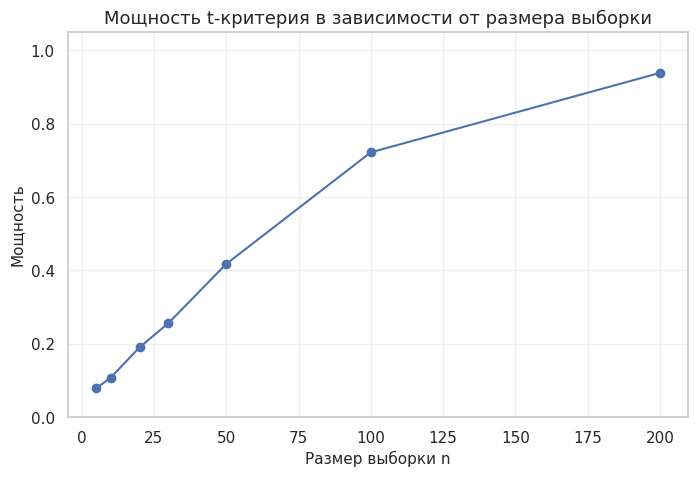

In [ ]:
sample_sizes = np.array([5, 10, 20, 30, 50, 100, 200])

powers = []

for n_current in sample_sizes:
    power = estimate_power(
        mu_true=10.5,
        mu_0=10,
        sigma=2,
        n=n_current,
        alpha=0.05,
        n_experiments=3000
    )

    powers.append(power)

plt.figure(figsize=(8, 5))

plt.plot(
    sample_sizes,
    powers,
    marker="o"
)


plt.xlabel("Размер выборки n")
plt.ylabel("Мощность")
plt.title("Мощность t-критерия в зависимости от размера выборки")
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)

plt.show()

#### Ошибки I и II рода: компромисс между α и β

Мы хотим проверить

$$
H_0:\mu=0
\qquad\text{против}\qquad
H_1:\mu=1.
$$

Уровень значимости $\alpha$ определяет, насколько строгим будет критерий.

Но чем строже критерий, тем сложнее обнаружить реальный эффект. Поэтому возникает компромисс:

$$
\alpha \downarrow
\quad\Longrightarrow\quad
\beta \uparrow.
$$

Проверим это экспериментально.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(42)

n = 20
mu_0 = 0
mu_1 = 1
sigma = 1
n_sim = 50_000

# Генерируем эксперименты при H0 и при H1
x_h0 = rng.normal(mu_0, sigma, size=(n_sim, n))
x_h1 = rng.normal(mu_1, sigma, size=(n_sim, n))

def t_statistic(x):
    return x.mean(axis=1) / (x.std(axis=1, ddof=1) / np.sqrt(x.shape[1]))

t_h0 = t_statistic(x_h0)
t_h1 = t_statistic(x_h1)

df = n - 1

alphas = np.linspace(0.001, 0.2, 100)

type1_error = []
type2_error = []

for alpha in alphas:
    critical_value = stats.t.ppf(1 - alpha / 2, df)

    # Двусторонний тест
    reject_h0 = np.abs(t_h0) > critical_value
    reject_h1 = np.abs(t_h1) > critical_value

    type1_error.append(np.mean(reject_h0))
    type2_error.append(np.mean(~reject_h1))

type1_error = np.array(type1_error)
type2_error = np.array(type2_error)

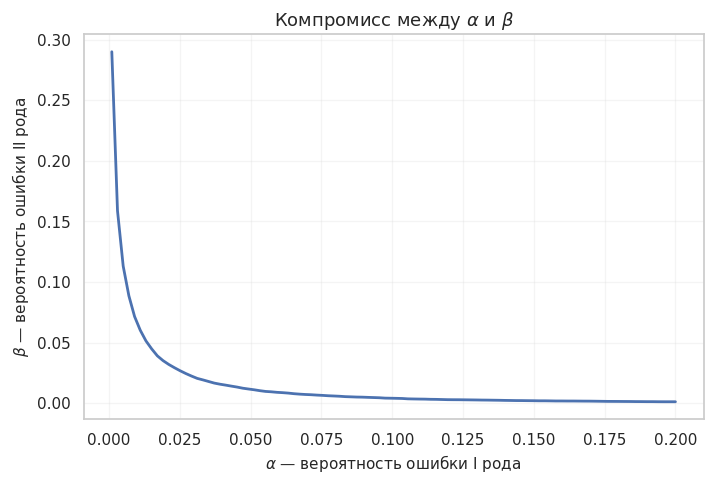

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(alphas, type2_error, linewidth=2)

plt.xlabel(r"$\alpha$ — вероятность ошибки I рода")
plt.ylabel(r"$\beta$ — вероятность ошибки II рода")
plt.title(r"Компромисс между $\alpha$ и $\beta$")
plt.grid(alpha=0.2)

plt.show()

Чем меньше $\alpha$, тем сильнее критическая область залезает на распределение статистики при истинности $H_1$. Поэтому вероятность ошибки второго рода выше.

Покажем это:
чем меньше $\alpha$, тем дальше от центра граница критической области.

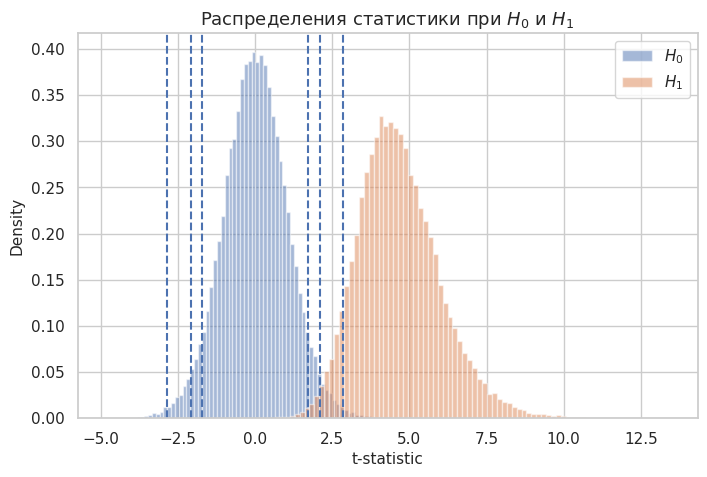

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(t_h0, bins=80, density=True, alpha=0.5, label=r"$H_0$")
plt.hist(t_h1, bins=80, density=True, alpha=0.5, label=r"$H_1$")

for alpha in [0.01, 0.05, 0.1]:
    critical_value = stats.t.ppf(1 - alpha / 2, df)
    plt.axvline(critical_value, linestyle="--")
    plt.axvline(-critical_value, linestyle="--")

plt.xlabel("t-statistic")
plt.ylabel("Density")
plt.title(r"Распределения статистики при $H_0$ и $H_1$")
plt.legend()
plt.show()

### 6.2* Permutation test как еще один пример

Предположим, у нас есть две выборки:

$$
X_1,\ldots,X_n
\qquad\text{и}\qquad
Y_1,\ldots,Y_m.
$$

Мы хотим проверить гипотезу

$$
H_0:\quad \mu_X=\mu_Y
$$

против альтернативы

$$
H_1:\quad \mu_X\neq\mu_Y.
$$

В классическом $t$-тесте мы знаем (при определённых предположениях), какое распределение имеет статистика теста при $H_0$.

**Permutation test** позволяет построить нулевое распределение непосредственно из данных.

Если $H_0$ верна, то принадлежность наблюдения к группе $X$ или $Y$ не должна влиять на его значение. Поэтому мы можем:

1. объединить две выборки;
2. случайным образом перемешать метки групп;
3. разделить данные обратно на две группы;
4. посчитать интересующую статистику;
5. повторить процедуру много раз.

В качестве статистики возьмём разность средних:

$$
T(X,Y)=\bar X-\bar Y.
$$

Полученные значения

$$
T_1^*,\ldots,T_B^*
$$

образуют **эмпирическое нулевое распределение** статистики.

Если наблюдаемая статистика $T_{\mathrm{obs}}$ находится далеко в хвосте этого распределения, то такая разница между группами маловероятна при $H_0$.

Для двустороннего теста permutation $p$-value можно оценить как

$$
\hat p =
\frac{1+\sum_{b=1}^B
\mathbf{1}\left(|T_b^*|\geq |T_{\mathrm{obs}}|\right)}
{B+1}.
$$

Добавление единицы в числитель и знаменатель делает оценку корректной даже при небольшом числе перестановок.


Observed difference: -0.597
Permutation p-value: 0.0042


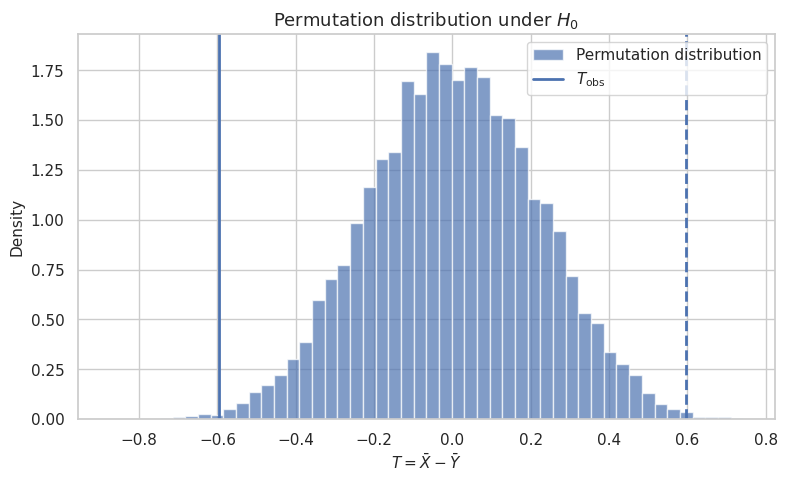

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as sps

rng = np.random.default_rng(42)

# Две выборки
n = 30
x = rng.normal(loc=0.0, scale=1.0, size=n)
y = rng.normal(loc=0.5, scale=1.0, size=n)

# Наблюдаемая статистика
t_obs = x.mean() - y.mean()

# Объединяем данные
pooled = np.concatenate([x, y])

# Permutation distribution
n_permutations = 10_000
t_perm = np.empty(n_permutations)

for i in range(n_permutations):
    permuted = rng.permutation(pooled)

    x_perm = permuted[:n]
    y_perm = permuted[n:]

    t_perm[i] = x_perm.mean() - y_perm.mean()

# Двустороннее permutation p-value
p_perm = (
    1 + np.sum(np.abs(t_perm) >= np.abs(t_obs))
) / (n_permutations + 1)

print(f"Observed difference: {t_obs:.3f}")
print(f"Permutation p-value: {p_perm:.4f}")

# Визуализация нулевого распределения
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(t_perm, bins=50, density=True, alpha=0.7,
        label="Permutation distribution")

ax.axvline(t_obs, lw=2, label=r"$T_{\mathrm{obs}}$")
ax.axvline(-t_obs, lw=2, ls="--")

ax.set_xlabel(r"$T = \bar X - \bar Y$")
ax.set_ylabel("Density")
ax.set_title("Permutation distribution under $H_0$")
ax.legend()

plt.show()

## 7.* Множественная проверка гипотез и поправка Бонферрони

До сих пор мы рассматривали одну статистическую гипотезу и контролировали вероятность ошибки I рода:

$$
P(\text{отвергнуть }H_0\mid H_0\text{ верна})\leq\alpha.
$$

Но на практике часто приходится проверять **сразу много гипотез**.

Например, в ML можно проверить, отличается ли качество модели от некоторого baseline сразу на нескольких датасетах, сравнить несколько моделей между собой или проверить влияние большого числа признаков.

Пусть мы проверяем $m$ гипотез:

$$
H_1,\ldots,H_m.
$$

Если для каждой гипотезы использовать уровень значимости $\alpha$, то вероятность сделать **хотя бы одну ложную ошибку I рода** становится существенно больше $\alpha$.

Обозначим событие ложного отклонения $H_i$ через $A_i$. Тогда вероятность хотя бы одной ошибки:

$$
P\left(\bigcup_{i=1}^m A_i\right).
$$

По неравенству Буля:

$$
P\left(\bigcup_{i=1}^m A_i\right)
\leq
\sum_{i=1}^m P(A_i).
$$

Если для каждой проверки

$$
P(A_i)\leq\alpha,
$$

то

$$
P(\text{хотя бы одна ошибка})
\leq m\alpha.
$$

Таким образом, при большом количестве тестов даже небольшой уровень значимости может привести к заметной вероятности получить хотя бы один **ложноположительный результат**.

### Поправка Бонферрони

Чтобы сохранить общий уровень значимости не больше $\alpha$, можно использовать для каждой из $m$ гипотез уровень

$$
\boxed{\alpha_{\mathrm{Bonf}}=\frac{\alpha}{m}}.
$$

Тогда

$$
P(\text{хотя бы одна ошибка I рода})
\leq
m\frac{\alpha}{m}
=
\alpha.
$$

Это и есть **поправка Бонферрони**.

Эквивалентно можно оставить исходные $p$-value и умножить их на число проверяемых гипотез:

$$
\boxed{
p_i^{\mathrm{Bonf}}=\min(mp_i,1)
}.
$$

После этого сравниваем скорректированные значения с исходным уровнем значимости $\alpha$.

### Почему поправка консервативна?

Бонферрони использует неравенство

$$
P\left(\bigcup_i A_i\right)
\leq
\sum_i P(A_i),
$$

которое не требует независимости гипотез.

Поэтому метод работает даже тогда, когда тесты зависимы. Однако за эту универсальность приходится платить: поправка может быть **консервативной**, особенно когда гипотез много.

В результате снижается вероятность ложных открытий, но одновременно уменьшается **мощность тестов** — реальные эффекты становится сложнее обнаружить.


In [ ]:
alpha = 0.05
m = 20
n_sims = 10_000

# Все H0 на самом деле верны
# При верной H0 p-value ~ Uniform(0, 1)
p_values = rng.uniform(0, 1, size=(n_sims, m))

# В каждом эксперименте проверяем m гипотез
rejected = p_values < alpha

# Была ли хотя бы одна ложная значимость?
at_least_one_false_positive = rejected.any(axis=1)

prob_false_discovery = np.mean(at_least_one_false_positive)

print(f"Число гипотез: {m}")
print(f"Уровень значимости одного теста: {alpha:.1%}")
print(f"Вероятность хотя бы одного ложного отклонения: "
      f"{prob_false_discovery:.1%}")

Число гипотез: 20
Уровень значимости одного теста: 5.0%
Вероятность хотя бы одного ложного отклонения: 64.3%


In [ ]:
alpha = 0.05
m = 20
n_sims = 10_000

alpha_bonf = alpha / m

p_values = rng.uniform(0, 1, size=(n_sims, m))

# Обычная проверка
rejected_standard = p_values < alpha

# Проверка с поправкой Бонферрони
rejected_bonferroni = p_values < alpha_bonf

# Хотя бы одно ложное отклонение
false_positive_standard = rejected_standard.any(axis=1)
false_positive_bonferroni = rejected_bonferroni.any(axis=1)

print(f"Обычный подход:       "
      f"{false_positive_standard.mean():.1%}")
print(f"Bonferroni:            "
      f"{false_positive_bonferroni.mean():.1%}")
print(f"Требуемый уровень:     {alpha:.1%}")

Обычный подход:       64.9%
Bonferroni:            5.2%
Требуемый уровень:     5.0%


## 8.* P-hacking

Мы уже увидели, что если проверять много гипотез, вероятность получить хотя бы один ложноположительный результат возрастает.

На практике возникает ещё одна проблема: исследователь может **многократно пробовать разные варианты анализа и остановиться, когда получит статистически значимый результат**.

Такое поведение называют **p-hacking**.

Например, исследователь может:

* проверить несколько гипотез и сообщить только значимые;
* попробовать несколько способов обработки данных;
* выбрать одну из нескольких моделей или статистических тестов;
* анализировать разные подгруппы;
* исключить некоторые наблюдения после просмотра результатов;
* продолжать собирать данные, пока результат не станет значимым.

Каждое из этих действий само по себе не обязательно является ошибкой. Проблема возникает тогда, когда **решение о том, какой анализ проводить или когда остановиться, принимается на основании уже увиденного результата**.

Рассмотрим простой пример.

Пусть на самом деле никакого эффекта нет:

$$
H_0:\mu_1=\mu_2.
$$

Если заранее выбрать один статистический тест и использовать уровень значимости

$$
\alpha=0.05,
$$

то при верной $H_0$ примерно в $5%$ экспериментов мы всё равно получим

$$
p<0.05.
$$

Это обычная ошибка I рода.

Но теперь представим, что исследователь проводит $m$ независимых анализов и публикует результат, если **хотя бы один** из них оказался значимым.

Тогда вероятность получить хотя бы одно ложное $p<0.05$ равна

$$
P(\text{хотя бы одно }p<0.05)
=
1-(1-\alpha)^m.
$$

Например, для $m=20$:

$$
1-0.95^{20}\approx0.64.
$$

То есть вероятность получить «статистически значимый» результат составляет уже около $64%$, хотя **реального эффекта нет вообще**.

Таким образом, p-hacking может создавать впечатление, что данные подтверждают некоторую гипотезу, хотя на самом деле полученная значимость является результатом перебора вариантов анализа.

Главная проблема здесь — не само значение $p<0.05$, а то, **сколько возможностей получить такое значение было использовано до того, как результат был представлен**.

Поэтому важно заранее фиксировать гипотезы и план анализа, а при множественных проверках учитывать количество проведённых тестов.


Посмотрим, как p-value меняется с изменением мощности выборки

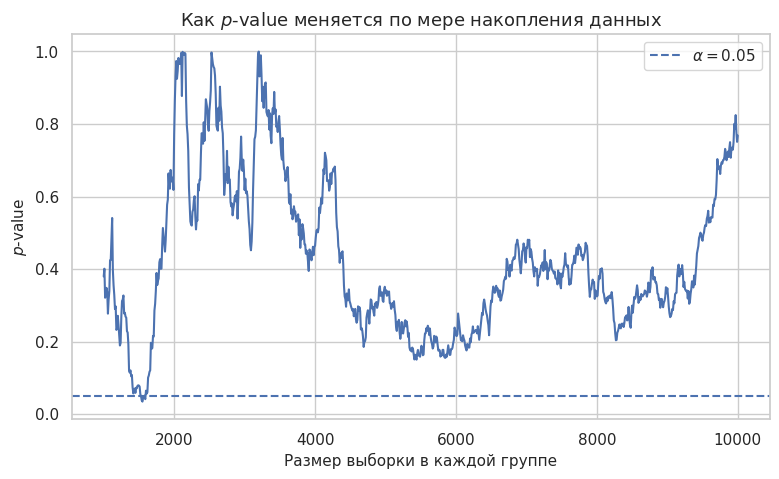

In [ ]:
# Одна симуляция

n_max = 10000
n_start = 1000
n_step = 10
x_all = rng.normal(0, 1, size=n_max)
y_all = rng.normal(0, 1, size=n_max)

sample_sizes = np.arange(n_start, n_max + 1, n_step)
p_values = []

for n in sample_sizes:
    _, p = sps.ttest_ind(x_all[:n], y_all[:n])
    p_values.append(p)

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(sample_sizes, p_values)
ax.axhline(alpha, linestyle="--", label=r"$\alpha=0.05$")

ax.set_xlabel("Размер выборки в каждой группе")
ax.set_ylabel("$p$-value")
ax.set_title("Как $p$-value меняется по мере накопления данных")
ax.legend()

plt.show()

А теперь к одним данным применим разные тесты

In [ ]:
alpha = 0.05
n_sims = 5_000

found_significant = np.zeros(n_sims, dtype=bool)

for sim in range(n_sims):

    # Никакого реального эффекта нет
    x = rng.lognormal(0, 0.5, size=50)
    y = rng.lognormal(0, 0.5, size=50)

    p_values = []

    # 1. Обычный t-test
    p_values.append(sps.ttest_ind(x, y).pvalue)

    # 2. Welch t-test
    p_values.append(
        sps.ttest_ind(x, y, equal_var=False).pvalue
    )

    # 3. Mann–Whitney
    p_values.append(
        sps.mannwhitneyu(x, y, alternative="two-sided").pvalue
    )

    # 4. Логарифмирование
    p_values.append(
        sps.ttest_ind(np.log(x), np.log(y)).pvalue
    )

    # 5. Убираем верхние 5% наблюдений
    x_trim = x[x < np.quantile(x, 0.95)]
    y_trim = y[y < np.quantile(y, 0.95)]

    p_values.append(
        sps.ttest_ind(x_trim, y_trim).pvalue
    )

    # Исследователь сообщает результат,
    # если хотя бы один вариант оказался значимым
    found_significant[sim] = np.min(p_values) < alpha

print(f"Вероятность найти значимый результат: "
      f"{found_significant.mean():.1%}")

Вероятность найти значимый результат: 9.1%
